# MRNet Multi-Plane Fusion with Hybrid Enhancements (NPY Volumes) with Test data
This notebook implements an **enhanced MRNet-style two-stage pipeline** with hybrid improvements:

## Architecture:
- **Stage 1**: Train **plane-specific hybrid experts** (axial / coronal / sagittal) using:
  - Configurable backbone (DenseNet121/ResNet/EfficientNet) with transfer learning
  - **Custom CNN branch** for domain-specific MRI features
  - **CBAM Attention** (Channel + Spatial) for feature refinement
  - **Slice Attention Aggregation** (learnable, instead of max pooling)
- **Stage 2**: Train a **fusion model** (logistic regression) on the three plane logits

## Hybrid Enhancements:
1. ✓ **Dual-Branch**: Pretrained backbone + Custom CNN
2. ✓ **CBAM Attention**: Channel & Spatial attention
3. ✓ **Slice Attention**: Learnable slice importance weights
4. ✓ **Configurable Backbone**: DenseNet121, ResNet, EfficientNet

## Data Preprocessing (NPY Volumes):
1. **Intensity Normalization**: Min-max → Z-score standardization
2. **Volume Standardization**: Entropy-based slice selection / zero-padding to 25 slices
3. **Data Augmentation** (training only, 50% probability):
   - Random rotations (±15°)
   - Random translations (±10%)
   - Random scaling (0.95-1.05)
   - Horizontal flipping
   - Brightness/contrast adjustments (±10%)
   - Gaussian noise addition (σ=0.02)
   - Elastic deformations (α=50, σ=5)


In [1]:
# 1) Set Paths, Task Selection, and Reproducibility
import os
import random
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms
from torchvision.models import densenet121, DenseNet121_Weights
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torchvision.models import alexnet, AlexNet_Weights

from sklearn.metrics import roc_auc_score, accuracy_score, precision_recall_fscore_support, confusion_matrix, roc_curve, auc

# ---- Config ----
DATA_ROOT = Path("./dataset")  # Original NPY dataset
TASK = "acl"  # one of: abnormal | acl | meniscus
PLANES = ["axial", "coronal", "sagittal"]
SPLITS = ["train", "valid"]

RUNS_DIR = Path("./runs_mrnet_hybrid_fusion_npy")
RUNS_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = torch.cuda.is_available()

try:
    from torch.amp import autocast as amp_autocast
    from torch.amp import GradScaler as AmpGradScaler
    scaler = AmpGradScaler(device_type="cuda", enabled=use_amp)
    autocast_ctx = lambda: amp_autocast(device_type="cuda", enabled=use_amp)
except Exception:
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
    autocast_ctx = lambda: torch.cuda.amp.autocast(enabled=use_amp)

# ---- Hybrid Config ----
HYPER: Dict[str, object] = {
    "img_size": 224,
    "train_batch": 2,
    "valid_batch": 2,
    "lr": 1e-4,
    "weight_decay": 1e-2,
    "epochs": 30,
    "num_workers": 0,  # Windows-safe default
    "pin_memory": torch.cuda.is_available(),
    "target_slices": 25,  # Standardized volume depth
    "train_sampling": "random",  # random | uniform
    "valid_sampling": "uniform",
    # Hybrid enhancements
    "backbone": "densenet121",  # alexnet | densenet121 | resnet18 | efficientnet_b0
    "use_custom_cnn": True,     # Enable custom CNN branch
    "use_cbam": True,           # Enable CBAM attention
    "use_slice_attention": True, # Enable slice attention aggregation
    "feature_dim": 256,         # Custom CNN output dimension
    "dropout": 0.4,
    # Data preprocessing
    "intensity_norm": True,     # Min-max + Z-score normalization
    "rotation": 15,             # ±15° rotation
    "translate": 0.1,           # ±10% translation
    "scale_range": (0.95, 1.05),# Random scaling
    "brightness": 0.1,          # Brightness adjustment (±10%)
    "contrast": 0.1,            # Contrast adjustment (±10%)
    "noise_std": 0.02,          # Gaussian noise std
    "elastic_alpha": 50,        # Elastic deformation alpha
    "elastic_sigma": 5,         # Elastic deformation sigma
    "augment_prob": 0.5,        # Probability of advanced augmentation
    # === NEW: AUC-Focused Improvements ===
    "use_focal_loss": True,     # Use Focal Loss instead of BCE
    "focal_gamma": 2.0,         # Focal Loss focusing parameter (1.5-2.0 recommended)
    "focal_alpha": None,        # Auto-computed from pos_ratio if None
    "slice_dropout": 0.2,       # Drop 20% of slices during training (10-30% effective)
    "slice_dropout_prob": 0.5,  # Probability of applying slice dropout
    "hybrid_slice_selection": True,  # Use hybrid (center + entropy) slice selection
    "center_slice_ratio": 0.4,  # 40% of slices from center region
}

# Backbone feature dimensions
BACKBONE_FEATURES = {
    "alexnet": 256,
    "densenet121": 1024,
    "resnet18": 512,
    "efficientnet_b0": 1280,
}

print("="*60)
print("HYBRID ENHANCED MRNet - TWO-STAGE FUSION (NPY)")
print("="*60)
print(f"DATA_ROOT: {DATA_ROOT.resolve()}")
print(f"Task: {TASK}")
print(f"Backbone: {HYPER['backbone']} ({BACKBONE_FEATURES[HYPER['backbone']]} features)")
print(f"Device: {device}, AMP: {use_amp}")
print("="*60)
print("Hybrid Enhancements:")
print(f"  ✓ Custom CNN Branch: {HYPER['use_custom_cnn']}")
print(f"  ✓ CBAM Attention: {HYPER['use_cbam']}")
print(f"  ✓ Slice Attention: {HYPER['use_slice_attention']}")
print("="*60)
print("🔥 NEW AUC-Focused Improvements:")
print(f"  ✓ Focal Loss: {HYPER['use_focal_loss']} (γ={HYPER['focal_gamma']})")
print(f"  ✓ Slice Dropout: {HYPER['slice_dropout']*100:.0f}% (p={HYPER['slice_dropout_prob']})")
print(f"  ✓ Hybrid Slice Selection: {HYPER['hybrid_slice_selection']}")
print("="*60)
print("Data Preprocessing (NPY Volumes):")
print(f"  ✓ Volume Standardization: {HYPER['target_slices']} slices")
print(f"  ✓ Intensity Normalization: {HYPER['intensity_norm']}")
print(f"  ✓ Rotation: ±{HYPER['rotation']}°")
print(f"  ✓ Translation: ±{int(HYPER['translate']*100)}%")
print(f"  ✓ Scaling: {HYPER['scale_range']}")
print(f"  ✓ Brightness/Contrast: ±{int(HYPER['brightness']*100)}%")
print(f"  ✓ Gaussian Noise: σ={HYPER['noise_std']}")
print(f"  ✓ Elastic Deformation: α={HYPER['elastic_alpha']}, σ={HYPER['elastic_sigma']}")
print("="*60)

c:\Users\ganee\.conda\envs\gpu\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


HYBRID ENHANCED MRNet - TWO-STAGE FUSION (NPY)
DATA_ROOT: C:\Users\ganee\Desktop\Research\Code\dataset
Task: acl
Backbone: densenet121 (1024 features)
Device: cuda, AMP: True
Hybrid Enhancements:
  ✓ Custom CNN Branch: True
  ✓ CBAM Attention: True
  ✓ Slice Attention: True
🔥 NEW AUC-Focused Improvements:
  ✓ Focal Loss: True (γ=2.0)
  ✓ Slice Dropout: 20% (p=0.5)
  ✓ Hybrid Slice Selection: True
Data Preprocessing (NPY Volumes):
  ✓ Volume Standardization: 25 slices
  ✓ Intensity Normalization: True
  ✓ Rotation: ±15°
  ✓ Translation: ±10%
  ✓ Scaling: (0.95, 1.05)
  ✓ Brightness/Contrast: ±10%
  ✓ Gaussian Noise: σ=0.02
  ✓ Elastic Deformation: α=50, σ=5


C:\Users\ganee\AppData\Local\Temp\ipykernel_16064\3130343012.py:55: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


In [2]:
# 2) Load MRNet CSV Labels and Re-Split Data
# ============================================================
# NEW DATA SPLIT STRATEGY:
# - Original Training Set (1130 exams) → Split into:
#   - New Training Set: ~1000 exams
#   - New Validation Set: ~130 exams
# - Original Validation Set (120 exams) → Test Set (HELD OUT completely)
# ============================================================

from sklearn.model_selection import train_test_split

def load_split_labels(data_root: Path, split: str, task: str) -> pd.DataFrame:
    csv_path = data_root / f"{split}-{task}.csv"
    df = pd.read_csv(csv_path, header=None, names=["exam_id", "label"])
    df["exam_id"] = df["exam_id"].astype(str).str.zfill(4)
    df["label"] = df["label"].astype(np.int64)
    df["split"] = split
    assert df["label"].isin([0, 1]).all(), "Labels must be binary 0/1"
    if df["exam_id"].duplicated().any():
        dups = df[df["exam_id"].duplicated()]["exam_id"].tolist()[:10]
        raise ValueError(f"Duplicate exam_id(s) in {csv_path}: {dups}")
    return df[["split", "exam_id", "label"]]

# Load original datasets
original_train = load_split_labels(DATA_ROOT, "train", TASK)
original_valid = load_split_labels(DATA_ROOT, "valid", TASK)

print("="*60)
print("ORIGINAL DATA SPLIT")
print("="*60)
print(f"Original Training Set: {len(original_train)} exams")
print(f"  - Positive: {original_train['label'].sum()}")
print(f"  - Negative: {len(original_train) - original_train['label'].sum()}")
print(f"Original Validation Set: {len(original_valid)} exams")
print(f"  - Positive: {original_valid['label'].sum()}")
print(f"  - Negative: {len(original_valid) - original_valid['label'].sum()}")
print("="*60)

# ============================================================
# RE-SPLIT: Take 120 exams from original training for new validation
# ============================================================
# Use stratified split to maintain class balance
NEW_VAL_SIZE = 120
NEW_TRAIN_SIZE = len(original_train) - NEW_VAL_SIZE  # ~1000 exams

# Stratified split to maintain class distribution
train_exam_ids, val_exam_ids = train_test_split(
    original_train['exam_id'].values,
    test_size=NEW_VAL_SIZE,
    random_state=SEED,
    stratify=original_train['label'].values  # Maintain class balance
)

# Create new train and validation DataFrames
new_train_index = original_train[original_train['exam_id'].isin(train_exam_ids)].copy()
new_train_index['split'] = 'train'

new_valid_index = original_train[original_train['exam_id'].isin(val_exam_ids)].copy()
new_valid_index['split'] = 'valid'  # Mark as 'valid' but will load from 'train' folder

# Test set: Original validation set (HELD OUT - never seen during training)
test_index = original_valid.copy()
test_index['split'] = 'test'

# Create combined exam_index for training and validation
# Note: The 'split' column now indicates the logical split, but data is in 'train' folder
exam_index = pd.concat([new_train_index, new_valid_index], ignore_index=True)

print("\n" + "="*60)
print("NEW DATA SPLIT (STRATIFIED)")
print("="*60)
print(f"New Training Set: {len(new_train_index)} exams (from original train folder)")
print(f"  - Positive: {new_train_index['label'].sum()} ({new_train_index['label'].mean()*100:.1f}%)")
print(f"  - Negative: {len(new_train_index) - new_train_index['label'].sum()}")
print(f"\nNew Validation Set: {len(new_valid_index)} exams (from original train folder)")
print(f"  - Positive: {new_valid_index['label'].sum()} ({new_valid_index['label'].mean()*100:.1f}%)")
print(f"  - Negative: {len(new_valid_index) - new_valid_index['label'].sum()}")
print(f"\n🔒 TEST SET (HELD OUT): {len(test_index)} exams (original valid folder)")
print(f"  - Positive: {test_index['label'].sum()} ({test_index['label'].mean()*100:.1f}%)")
print(f"  - Negative: {len(test_index) - test_index['label'].sum()}")
print("  ⚠️  This test set will NOT be used during training!")
print("="*60)

# Sanity check
assert len(new_train_index) + len(new_valid_index) == len(original_train), "Split sizes don't match!"
assert set(new_train_index['exam_id']).isdisjoint(set(new_valid_index['exam_id'])), "Train/Val overlap!"
assert set(exam_index['exam_id']).isdisjoint(set(test_index['exam_id'])), "Train+Val/Test overlap!"

print("\n✅ Data split validation passed!")
print(f"   - No overlap between train and validation")
print(f"   - No overlap between train+val and test")

exam_index.head()

ORIGINAL DATA SPLIT
Original Training Set: 1130 exams
  - Positive: 208
  - Negative: 922
Original Validation Set: 120 exams
  - Positive: 54
  - Negative: 66

NEW DATA SPLIT (STRATIFIED)
New Training Set: 1010 exams (from original train folder)
  - Positive: 186 (18.4%)
  - Negative: 824

New Validation Set: 120 exams (from original train folder)
  - Positive: 22 (18.3%)
  - Negative: 98

🔒 TEST SET (HELD OUT): 120 exams (original valid folder)
  - Positive: 54 (45.0%)
  - Negative: 66
  ⚠️  This test set will NOT be used during training!

✅ Data split validation passed!
   - No overlap between train and validation
   - No overlap between train+val and test


,split,exam_id,label
0,train,0000,0
1,train,0001,1
2,train,0003,0
3,train,0004,0
4,train,0005,0


In [3]:
# 3) Dataset I/O: Load NPY Volumes + Sanity Check
def load_npy_volume(data_root: Path, split: str, plane: str, exam_id: str) -> np.ndarray:
    """Load a single NPY volume file.
    
    Note: For the new data split strategy, logical 'valid' split data is stored 
    in the 'train' folder. Use get_physical_split() to map logical to physical splits.
    """
    npy_path = data_root / split / plane / f"{exam_id}.npy"
    if not npy_path.exists():
        return None
    return np.load(npy_path)  # Shape: (S, H, W)

def get_physical_split(exam_id: str, logical_split: str) -> str:
    """Map logical split to physical folder location.
    
    Since we re-split the data:
    - 'train' logical → 'train' folder (original training exams)
    - 'valid' logical → 'train' folder (carved from original training)
    - 'test' logical → 'valid' folder (original validation exams)
    """
    if logical_split in ['train', 'valid']:
        return 'train'  # Both new train and new valid come from original train folder
    elif logical_split == 'test':
        return 'valid'  # Test set comes from original valid folder
    return logical_split

def sanity_check_npy(index_df: pd.DataFrame, data_root: Path, planes: List[str], max_report: int = 5) -> None:
    """Check that NPY files exist for all exams."""
    missing = []
    slice_counts = {plane: [] for plane in planes}
    
    for _, row in index_df.sample(n=min(30, len(index_df)), random_state=SEED).iterrows():
        logical_split = row["split"]
        physical_split = get_physical_split(row["exam_id"], logical_split)
        exam_id = row["exam_id"]
        for plane in planes:
            vol = load_npy_volume(data_root, physical_split, plane, exam_id)
            if vol is None:
                missing.append((logical_split, plane, exam_id))
                if len(missing) >= max_report:
                    break
            else:
                slice_counts[plane].append(vol.shape[0])
        if len(missing) >= max_report:
            break
    
    if missing:
        print("Warning: missing NPY file(s):")
        for item in missing:
            print("  ", item)
    else:
        print("✅ All checked exams have NPY files for all planes.")
    
    # Print slice statistics
    print("\nSlice count statistics (sampled):")
    for plane in planes:
        if slice_counts[plane]:
            counts = np.array(slice_counts[plane])
            print(f"  {plane}: min={counts.min()}, max={counts.max()}, mean={counts.mean():.1f}")

sanity_check_npy(exam_index, DATA_ROOT, PLANES)

✅ All checked exams have NPY files for all planes.

Slice count statistics (sampled):
  axial: min=19, max=46, mean=32.2
  coronal: min=17, max=42, mean=27.3
  sagittal: min=18, max=47, mean=29.5


# 4) Hybrid Components: CBAM, Custom CNN, Slice Attention

## Architecture Enhancement:
- **CBAM**: Channel attention (which features matter) + Spatial attention (where to look)
- **Custom CNN**: Domain-specific MRI feature extraction (4 conv blocks)
- **Slice Attention**: Learnable aggregation replacing max pooling

The hybrid slice features are computed as:
$$h_i = \text{Concat}(\text{CBAM}(F_i^{backbone}), F_i^{custom})$$
$$v = \sum_i \alpha_i \cdot h_i, \quad \alpha_i = \text{softmax}(\text{Attn}(h_i))$$

In [4]:
# 4a) Advanced Data Preprocessing Methods for NPY Volumes
import scipy.ndimage as ndimage
from scipy.stats import entropy

# ==================== INTENSITY NORMALIZATION ====================

def min_max_normalize(volume: np.ndarray) -> np.ndarray:
    """Min-max normalization to scale pixel values to [0, 1]."""
    v_min = volume.min()
    v_max = volume.max()
    if v_max - v_min > 0:
        return (volume - v_min) / (v_max - v_min)
    return volume

def z_score_normalize(volume: np.ndarray) -> np.ndarray:
    """Z-score normalization to standardize pixel intensity distributions."""
    mean = volume.mean()
    std = volume.std()
    if std > 0:
        return (volume - mean) / std
    return volume - mean

def intensity_normalize(volume: np.ndarray) -> np.ndarray:
    """Combined intensity normalization: min-max → z-score."""
    volume = min_max_normalize(volume)
    volume = z_score_normalize(volume)
    return volume

# ==================== VOLUME STANDARDIZATION ====================

def calculate_slice_entropy(slice_2d: np.ndarray) -> float:
    """Calculate entropy of a 2D slice. Higher entropy = more informative."""
    slice_normalized = ((slice_2d - slice_2d.min()) / (slice_2d.max() - slice_2d.min() + 1e-8) * 255).astype(np.uint8)
    hist, _ = np.histogram(slice_normalized.flatten(), bins=256, range=(0, 256), density=True)
    hist = hist[hist > 0]
    return entropy(hist)

def entropy_based_slice_selection(volume: np.ndarray, target_slices: int = 25) -> np.ndarray:
    """Select slices based on entropy while preserving structural continuity."""
    n_slices = volume.shape[0]
    
    if n_slices <= target_slices:
        return volume
    
    # Calculate entropy for each slice
    entropies = np.array([calculate_slice_entropy(volume[i]) for i in range(n_slices)])
    
    # Divide into segments and select highest entropy slice from each
    n_segments = target_slices
    segment_size = n_slices / n_segments
    
    selected_indices = []
    for seg in range(n_segments):
        start_idx = int(seg * segment_size)
        end_idx = int((seg + 1) * segment_size)
        segment_entropies = entropies[start_idx:end_idx]
        best_local_idx = np.argmax(segment_entropies)
        selected_indices.append(start_idx + best_local_idx)
    
    return volume[selected_indices]

# ==================== NEW: HYBRID SLICE SELECTION ====================

def hybrid_slice_selection(volume: np.ndarray, target_slices: int = 25, 
                           center_ratio: float = 0.4) -> np.ndarray:
    """
    Hybrid slice selection combining center preservation + entropy-based selection.
    
    Strategy:
    1. ALWAYS keep center slices (ACL/meniscus-critical regions)
    2. Fill remaining slots with high-entropy slices from periphery
    3. Maintain anatomical continuity by sorting final indices
    
    Args:
        volume: (S, H, W) input volume
        target_slices: desired number of output slices
        center_ratio: fraction of target_slices to take from center (default 40%)
    
    Returns:
        Selected volume with target_slices
    """
    n_slices = volume.shape[0]
    
    if n_slices <= target_slices:
        return volume
    
    # Step 1: Calculate how many slices from center vs entropy-based
    n_center = int(target_slices * center_ratio)
    n_entropy = target_slices - n_center
    
    # Step 2: Select center slices (preserves pathology-critical regions)
    center_start = (n_slices - n_center) // 2
    center_end = center_start + n_center
    center_indices = list(range(center_start, center_end))
    
    # Step 3: Calculate entropy for peripheral slices only
    peripheral_indices = list(range(0, center_start)) + list(range(center_end, n_slices))
    
    if len(peripheral_indices) > 0 and n_entropy > 0:
        entropies = np.array([calculate_slice_entropy(volume[i]) for i in peripheral_indices])
        
        # Select top n_entropy slices by entropy from periphery
        if len(peripheral_indices) >= n_entropy:
            top_entropy_local = np.argsort(entropies)[-n_entropy:]
            entropy_indices = [peripheral_indices[i] for i in top_entropy_local]
        else:
            entropy_indices = peripheral_indices
    else:
        entropy_indices = []
    
    # Step 4: Combine and sort to maintain anatomical order
    all_indices = sorted(set(center_indices + entropy_indices))
    
    # If we have too many (due to overlap), take uniformly spaced subset
    if len(all_indices) > target_slices:
        step = len(all_indices) / target_slices
        all_indices = [all_indices[int(i * step)] for i in range(target_slices)]
    
    # If we have too few, fill with highest entropy remaining slices
    while len(all_indices) < target_slices:
        remaining = [i for i in range(n_slices) if i not in all_indices]
        if not remaining:
            break
        entropies_remaining = [calculate_slice_entropy(volume[i]) for i in remaining]
        best_idx = remaining[np.argmax(entropies_remaining)]
        all_indices.append(best_idx)
        all_indices = sorted(all_indices)
    
    return volume[all_indices[:target_slices]]

def standardize_volume(volume: np.ndarray, target_slices: int = 25, 
                       use_hybrid: bool = True, center_ratio: float = 0.4) -> np.ndarray:
    """Standardize volume to fixed number of slices."""
    n_slices = volume.shape[0]
    
    if n_slices == target_slices:
        return volume
    elif n_slices < target_slices:
        # Zero-padding (centered)
        pad_total = target_slices - n_slices
        pad_before = pad_total // 2
        pad_after = pad_total - pad_before
        padded = np.zeros((target_slices, volume.shape[1], volume.shape[2]), dtype=volume.dtype)
        padded[pad_before:pad_before + n_slices] = volume
        return padded
    else:
        # Use hybrid or entropy-only slice selection
        if use_hybrid:
            return hybrid_slice_selection(volume, target_slices, center_ratio)
        else:
            return entropy_based_slice_selection(volume, target_slices)

# ==================== TENSOR AUGMENTATION TRANSFORMS ====================

def min_max_normalize_tensor(x: torch.Tensor) -> torch.Tensor:
    """Min-max normalization for tensors."""
    v_min = x.min()
    v_max = x.max()
    if v_max - v_min > 0:
        return (x - v_min) / (v_max - v_min)
    return x

def z_score_normalize_tensor(x: torch.Tensor) -> torch.Tensor:
    """Z-score normalization for tensors."""
    mean = x.mean()
    std = x.std()
    if std > 0:
        return (x - mean) / std
    return x - mean

class IntensityNormalize:
    """Combined intensity normalization: min-max → z-score."""
    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        x = min_max_normalize_tensor(x)
        x = z_score_normalize_tensor(x)
        return x

class RandomBrightnessContrast:
    """Random brightness and contrast adjustments."""
    def __init__(self, brightness: float = 0.1, contrast: float = 0.1):
        self.brightness = brightness
        self.contrast = contrast
    
    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        brightness_factor = 1 + np.random.uniform(-self.brightness, self.brightness)
        x = x * brightness_factor
        contrast_factor = 1 + np.random.uniform(-self.contrast, self.contrast)
        mean = x.mean()
        x = (x - mean) * contrast_factor + mean
        return x

class GaussianNoise:
    """Gaussian noise addition."""
    def __init__(self, std: float = 0.02):
        self.std = std
    
    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        noise = torch.randn_like(x) * self.std
        return x + noise

class ElasticDeformation:
    """Elastic deformations to simulate anatomical variability."""
    def __init__(self, alpha: float = 50, sigma: float = 5):
        self.alpha = alpha
        self.sigma = sigma
    
    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        _, h, w = x.shape
        dx = ndimage.gaussian_filter((np.random.rand(h, w) * 2 - 1), self.sigma) * self.alpha
        dy = ndimage.gaussian_filter((np.random.rand(h, w) * 2 - 1), self.sigma) * self.alpha
        
        y_coord, x_coord = np.meshgrid(np.arange(h), np.arange(w), indexing='ij')
        indices_x = np.clip(x_coord + dx, 0, w - 1).astype(np.float32)
        indices_y = np.clip(y_coord + dy, 0, h - 1).astype(np.float32)
        
        grid_x = 2.0 * indices_x / (w - 1) - 1.0
        grid_y = 2.0 * indices_y / (h - 1) - 1.0
        grid = torch.stack([
            torch.from_numpy(grid_x),
            torch.from_numpy(grid_y)
        ], dim=-1).unsqueeze(0).float()
        
        x_batched = x.unsqueeze(0)
        warped = F.grid_sample(x_batched, grid, mode='bilinear', padding_mode='zeros', align_corners=True)
        return warped.squeeze(0)

class RandomAugmentation:
    """Apply augmentations with a given probability."""
    def __init__(self, augmentations: List, p: float = 0.5):
        self.augmentations = augmentations
        self.p = p
    
    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        if np.random.random() < self.p:
            for aug in self.augmentations:
                x = aug(x)
        return x

print("="*60)
print("Advanced Data Preprocessing Methods (NPY Volumes)")
print("="*60)
print("\n1. Volume Standardization:")
if HYPER.get("hybrid_slice_selection", True):
    print(f"   ✓ HYBRID slice selection (center {int(HYPER.get('center_slice_ratio', 0.4)*100)}% + entropy)")
    print("   - Preserves ACL/meniscus-critical center slices")
    print("   - Adds high-entropy peripheral slices")
    print("   - Maintains anatomical continuity")
else:
    print("   - Entropy-based slice selection for volumes > 25 slices")
print("   - Zero-padding for volumes < 25 slices")
print("\n2. Intensity Normalization:")
print("   - Min-max normalization to [0, 1]")
print("   - Z-score normalization for standardization")
print("\n3. Advanced Augmentations (50% probability):")
print("   - Random brightness/contrast adjustments (±10%)")
print("   - Gaussian noise addition (σ=0.02)")
print("   - Elastic deformations (α=50, σ=5)")
print("="*60)

Advanced Data Preprocessing Methods (NPY Volumes)

1. Volume Standardization:
   ✓ HYBRID slice selection (center 40% + entropy)
   - Preserves ACL/meniscus-critical center slices
   - Adds high-entropy peripheral slices
   - Maintains anatomical continuity
   - Zero-padding for volumes < 25 slices

2. Intensity Normalization:
   - Min-max normalization to [0, 1]
   - Z-score normalization for standardization

3. Advanced Augmentations (50% probability):
   - Random brightness/contrast adjustments (±10%)
   - Gaussian noise addition (σ=0.02)
   - Elastic deformations (α=50, σ=5)


In [5]:
# 4b) Transforms for NPY Volume Processing
IMG_SIZE = int(HYPER["img_size"])
TARGET_SLICES = int(HYPER["target_slices"])

# Advanced augmentations (applied to each slice tensor)
advanced_augmentations = RandomAugmentation([
    RandomBrightnessContrast(brightness=0.1, contrast=0.1),
    GaussianNoise(std=0.02),
    ElasticDeformation(alpha=50, sigma=5),
], p=0.5)

class NPYSliceTransform:
    """Transform for individual slices from NPY volumes."""
    def __init__(self, img_size: int, is_train: bool = True, advanced_augs=None):
        self.img_size = img_size
        self.is_train = is_train
        self.advanced_augs = advanced_augs
        self.intensity_normalizer = IntensityNormalize()
        
        # ImageNet normalization
        self.normalize = transforms.Normalize(
            mean=[0.485, 0.456, 0.406], 
            std=[0.229, 0.224, 0.225]
        )
    
    def __call__(self, slice_2d: np.ndarray) -> torch.Tensor:
        """
        Transform a single 2D slice.
        Args:
            slice_2d: (H, W) numpy array
        Returns:
            tensor: (3, img_size, img_size) tensor
        """
        # Convert to tensor and add channel dim
        x = torch.from_numpy(slice_2d).float().unsqueeze(0)  # (1, H, W)
        
        # Resize to target size
        x = F.interpolate(x.unsqueeze(0), size=(self.img_size, self.img_size), 
                          mode='bilinear', align_corners=False).squeeze(0)  # (1, H, W)
        
        # Expand to 3 channels for backbone compatibility
        x = x.repeat(3, 1, 1)  # (3, H, W)
        
        # Apply training augmentations
        if self.is_train:
            # Random rotation (±15°)
            if np.random.random() > 0.5:
                angle = np.random.uniform(-15, 15)
                x = transforms.functional.rotate(x, angle)
            
            # Random affine (translation + scaling)
            if np.random.random() > 0.5:
                translate = (np.random.uniform(-0.1, 0.1) * self.img_size,
                            np.random.uniform(-0.1, 0.1) * self.img_size)
                scale = np.random.uniform(0.95, 1.05)
                x = transforms.functional.affine(x, angle=0, translate=translate, scale=scale, shear=0)
            
            # Random horizontal flip
            if np.random.random() > 0.5:
                x = transforms.functional.hflip(x)
        
        # Intensity normalization
        x = self.intensity_normalizer(x)
        
        # Advanced augmentations (brightness, contrast, noise, elastic)
        if self.is_train and self.advanced_augs:
            x = self.advanced_augs(x)
        
        # ImageNet normalization
        x = self.normalize(x)
        
        return x

# Create transforms
train_tf = NPYSliceTransform(IMG_SIZE, is_train=True, advanced_augs=advanced_augmentations)
valid_tf = NPYSliceTransform(IMG_SIZE, is_train=False, advanced_augs=None)

print("="*60)
print("NPY Volume Preprocessing Pipeline")
print("="*60)
print(f"\nVolume Standardization: {TARGET_SLICES} slices")
print("  - Entropy-based selection for reduction")
print("  - Zero-padding for shorter sequences")
print("\nIntensity Normalization (all data):")
print("  ✓ Min-max normalization to [0, 1]")
print("  ✓ Z-score normalization")
print("\nTraining Augmentations:")
print("  ✓ Random rotation (±15°)")
print("  ✓ Random translation (±10%)")
print("  ✓ Random scaling (0.95-1.05)")
print("  ✓ Random horizontal flip (50%)")
print("  ✓ Random brightness/contrast (±10%) [50% prob]")
print("  ✓ Gaussian noise (σ=0.02) [50% prob]")
print("  ✓ Elastic deformation (α=50, σ=5) [50% prob]")
print("="*60)

NPY Volume Preprocessing Pipeline

Volume Standardization: 25 slices
  - Entropy-based selection for reduction
  - Zero-padding for shorter sequences

Intensity Normalization (all data):
  ✓ Min-max normalization to [0, 1]
  ✓ Z-score normalization

Training Augmentations:
  ✓ Random rotation (±15°)
  ✓ Random translation (±10%)
  ✓ Random scaling (0.95-1.05)
  ✓ Random horizontal flip (50%)
  ✓ Random brightness/contrast (±10%) [50% prob]
  ✓ Gaussian noise (σ=0.02) [50% prob]
  ✓ Elastic deformation (α=50, σ=5) [50% prob]


In [6]:
# 5) Plane-Specific NPY Dataset + DataLoader with Slice Dropout
# ============================================================
# IMPORTANT: After re-split, both train and valid data come from 
# original 'train' folder. The 'split' column is logical, but 
# actual data folder is determined by 'data_folder' parameter.
# ============================================================

class PlaneNPYDataset(Dataset):
    """
    Dataset for loading NPY volumes with preprocessing:
    - Intensity normalization (min-max + z-score)
    - Volume standardization (hybrid/entropy-based selection / zero-padding)
    - Slice dropout during training (improves AUC robustness)
    - Data augmentation (training only)
    
    NEW: Supports re-split where train/valid data comes from same folder.
    """
    def __init__(
        self,
        index_df: pd.DataFrame,
        data_root: Path,
        logical_split: str,       # 'train', 'valid', or 'test' (logical split)
        data_folder: str,         # Actual folder name: 'train' or 'valid'
        plane: str,
        target_slices: int,
        transform,
        seed: int = 42,
        slice_dropout: float = 0.0,      # Fraction of slices to drop (0.1-0.3)
        slice_dropout_prob: float = 0.5,  # Probability of applying slice dropout
        use_hybrid_selection: bool = True,
        center_slice_ratio: float = 0.4,
    ) -> None:
        super().__init__()
        # Filter by logical split (train/valid/test)
        self.df = index_df[index_df["split"] == logical_split].reset_index(drop=True)
        self.data_root = data_root
        self.logical_split = logical_split
        self.data_folder = data_folder  # Actual folder to load from
        self.plane = plane
        self.target_slices = target_slices
        self.transform = transform
        self.rng = np.random.default_rng(seed)
        
        # Slice dropout (training only)
        self.slice_dropout = slice_dropout if logical_split == "train" else 0.0
        self.slice_dropout_prob = slice_dropout_prob
        
        # Hybrid slice selection
        self.use_hybrid_selection = use_hybrid_selection
        self.center_slice_ratio = center_slice_ratio

    def __len__(self) -> int:
        return len(self.df)
    
    def apply_slice_dropout(self, x: torch.Tensor) -> torch.Tensor:
        """
        Randomly zero out slices during training to prevent overfitting.
        
        This forces the model to:
        - Not rely on specific dominant slices
        - Learn more robust global features
        - Improve ranking (AUC) by better generalization
        
        Args:
            x: (K, C, H, W) tensor of slices
        Returns:
            x with some slices zeroed out
        """
        if self.slice_dropout <= 0 or np.random.random() > self.slice_dropout_prob:
            return x
        
        k = x.shape[0]
        n_drop = max(1, int(k * self.slice_dropout))
        
        # Don't drop center slices (keep pathology-critical regions)
        center_start = k // 4
        center_end = k - k // 4
        
        # Candidate slices for dropout (periphery only)
        peripheral_indices = list(range(0, center_start)) + list(range(center_end, k))
        
        if len(peripheral_indices) >= n_drop:
            drop_indices = np.random.choice(peripheral_indices, size=n_drop, replace=False)
        else:
            # If not enough peripheral slices, drop from anywhere
            drop_indices = np.random.choice(k, size=min(n_drop, k-1), replace=False)
        
        # Zero out selected slices
        x_dropped = x.clone()
        for idx in drop_indices:
            x_dropped[idx] = 0
        
        return x_dropped

    def __getitem__(self, i: int):
        exam_id = self.df.loc[i, "exam_id"]
        label = float(self.df.loc[i, "label"])
        
        # Load NPY volume from actual data folder (not logical split)
        npy_path = self.data_root / self.data_folder / self.plane / f"{exam_id}.npy"
        volume = np.load(npy_path)  # Shape: (S, H, W)
        
        # 1. Intensity normalization on raw volume
        volume = intensity_normalize(volume)
        
        # 2. Standardize to target_slices (using hybrid or entropy-only)
        volume = standardize_volume(
            volume, 
            self.target_slices, 
            use_hybrid=self.use_hybrid_selection,
            center_ratio=self.center_slice_ratio
        )
        
        # 3. Transform each slice
        slices = []
        for s in range(volume.shape[0]):
            slice_tensor = self.transform(volume[s])  # (3, H, W)
            slices.append(slice_tensor)
        
        x = torch.stack(slices, dim=0)  # (K, 3, H, W)
        
        # 4. Apply slice dropout (training only)
        if self.logical_split == "train" and self.slice_dropout > 0:
            x = self.apply_slice_dropout(x)
        
        y = torch.tensor(label, dtype=torch.float32)
        
        return x, y, exam_id


def make_loaders_for_plane(plane: str):
    """
    Create train and validation dataloaders for a specific plane.
    
    NEW: After re-split, both train and valid data come from 'train' folder.
    """
    train_ds = PlaneNPYDataset(
        exam_index, DATA_ROOT, 
        logical_split="train",    # Logical split
        data_folder="train",      # Actual data folder
        plane=plane, 
        target_slices=TARGET_SLICES, 
        transform=train_tf, 
        seed=SEED,
        slice_dropout=float(HYPER.get("slice_dropout", 0.2)),
        slice_dropout_prob=float(HYPER.get("slice_dropout_prob", 0.5)),
        use_hybrid_selection=bool(HYPER.get("hybrid_slice_selection", True)),
        center_slice_ratio=float(HYPER.get("center_slice_ratio", 0.4)),
    )
    valid_ds = PlaneNPYDataset(
        exam_index, DATA_ROOT, 
        logical_split="valid",    # Logical split (from original train)
        data_folder="train",      # Data is in 'train' folder!
        plane=plane, 
        target_slices=TARGET_SLICES, 
        transform=valid_tf, 
        seed=SEED,
        slice_dropout=0.0,  # No dropout for validation
        slice_dropout_prob=0.0,
        use_hybrid_selection=bool(HYPER.get("hybrid_slice_selection", True)),
        center_slice_ratio=float(HYPER.get("center_slice_ratio", 0.4)),
    )
    train_loader = DataLoader(
        train_ds,
        batch_size=int(HYPER["train_batch"]),
        shuffle=True,
        num_workers=int(HYPER["num_workers"]),
        pin_memory=bool(HYPER["pin_memory"]),
    )
    valid_loader = DataLoader(
        valid_ds,
        batch_size=int(HYPER["valid_batch"]),
        shuffle=False,
        num_workers=int(HYPER["num_workers"]),
        pin_memory=bool(HYPER["pin_memory"]),
    )
    return train_loader, valid_loader


def make_test_loader_for_plane(plane: str):
    """
    Create test dataloader for a specific plane.
    
    TEST SET: Uses original 'valid' folder data (HELD OUT completely).
    This should ONLY be used for final evaluation after all training is complete.
    """
    test_ds = PlaneNPYDataset(
        test_index, DATA_ROOT,    # Use test_index (original valid set)
        logical_split="test",     # Logical split
        data_folder="valid",      # Data is in original 'valid' folder!
        plane=plane, 
        target_slices=TARGET_SLICES, 
        transform=valid_tf,       # No augmentation for test
        seed=SEED,
        slice_dropout=0.0,        # No dropout for test
        slice_dropout_prob=0.0,
        use_hybrid_selection=bool(HYPER.get("hybrid_slice_selection", True)),
        center_slice_ratio=float(HYPER.get("center_slice_ratio", 0.4)),
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=int(HYPER["valid_batch"]),
        shuffle=False,
        num_workers=int(HYPER["num_workers"]),
        pin_memory=bool(HYPER["pin_memory"]),
    )
    return test_loader


# Smoke-check one sample from each split
print("="*60)
print("DATA LOADER VERIFICATION")
print("="*60)

# Training loader
tmp_train_loader, tmp_valid_loader = make_loaders_for_plane("axial")
xb, yb, eid = next(iter(tmp_train_loader))
print(f"\n✅ TRAIN Loader ({len(tmp_train_loader.dataset)} samples):")
print(f"   Batch x: {xb.shape}, dtype: {xb.dtype}")
print(f"   Batch y: {yb.shape}, exam_id[0]: {eid[0]}")

# Validation loader
xb, yb, eid = next(iter(tmp_valid_loader))
print(f"\n✅ VALID Loader ({len(tmp_valid_loader.dataset)} samples):")
print(f"   Batch x: {xb.shape}, dtype: {xb.dtype}")
print(f"   Batch y: {yb.shape}, exam_id[0]: {eid[0]}")

# Test loader
tmp_test_loader = make_test_loader_for_plane("axial")
xb, yb, eid = next(iter(tmp_test_loader))
print(f"\n🔒 TEST Loader ({len(tmp_test_loader.dataset)} samples) - HELD OUT:")
print(f"   Batch x: {xb.shape}, dtype: {xb.dtype}")
print(f"   Batch y: {yb.shape}, exam_id[0]: {eid[0]}")

print(f"\nExpected shape: (batch, slices={TARGET_SLICES}, channels=3, H={IMG_SIZE}, W={IMG_SIZE})")
print("="*60)
print(f"\n🔥 Slice Dropout: {HYPER.get('slice_dropout', 0.2)*100:.0f}% (p={HYPER.get('slice_dropout_prob', 0.5)})")
print(f"🔥 Hybrid Slice Selection: {HYPER.get('hybrid_slice_selection', True)}")
print("\n⚠️  REMINDER: Test set should ONLY be used for final evaluation!")

DATA LOADER VERIFICATION

✅ TRAIN Loader (1010 samples):
   Batch x: torch.Size([2, 25, 3, 224, 224]), dtype: torch.float32
   Batch y: torch.Size([2]), exam_id[0]: 0944

✅ VALID Loader (120 samples):
   Batch x: torch.Size([2, 25, 3, 224, 224]), dtype: torch.float32
   Batch y: torch.Size([2]), exam_id[0]: 0002

🔒 TEST Loader (120 samples) - HELD OUT:
   Batch x: torch.Size([2, 25, 3, 224, 224]), dtype: torch.float32
   Batch y: torch.Size([2]), exam_id[0]: 1130

Expected shape: (batch, slices=25, channels=3, H=224, W=224)

🔥 Slice Dropout: 20% (p=0.5)
🔥 Hybrid Slice Selection: True

⚠️  REMINDER: Test set should ONLY be used for final evaluation!


In [9]:
# 6) Hybrid Components: CBAM Attention, Custom CNN, Slice Attention, Focal Loss

# ============== FOCAL LOSS (AUC-FOCUSED) ==============
class FocalLoss(nn.Module):
    """
    Focal Loss for improved class separation and hard example mining.
    
    FL(p_t) = -α_t * (1 - p_t)^γ * log(p_t)
    
    Why this helps AUC:
    - Downweights easy examples (well-classified)
    - Focuses learning on hard positives vs hard negatives
    - Improves class separation → better ranking
    
    Recommended settings:
    - γ (gamma): 1.5-2.0 (higher = more focus on hard examples)
    - α (alpha): ~pos_ratio for class imbalance
    
    Args:
        gamma: Focusing parameter (default 2.0)
        alpha: Class weight for positive class (auto-computed if None)
        reduction: 'mean', 'sum', or 'none'
    """
    def __init__(self, gamma: float = 2.0, alpha: float = None, reduction: str = 'mean'):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.reduction = reduction
    
    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        Args:
            logits: (N,) raw logits from model
            targets: (N,) binary labels {0, 1}
        """
        probs = torch.sigmoid(logits)
        
        # Binary cross entropy component
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        
        # p_t = p if y=1 else 1-p
        p_t = probs * targets + (1 - probs) * (1 - targets)
        
        # Focal weight: (1 - p_t)^gamma
        focal_weight = (1 - p_t) ** self.gamma
        
        # Apply class weights (alpha)
        if self.alpha is not None:
            alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
            focal_loss = alpha_t * focal_weight * bce
        else:
            focal_loss = focal_weight * bce
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss


# ============== CBAM Attention ==============
class ChannelAttention(nn.Module):
    """Channel Attention: Learns WHICH feature channels are important."""
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False)
        )
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        b, c, _, _ = x.size()
        avg_out = self.fc(self.avg_pool(x).view(b, c))
        max_out = self.fc(self.max_pool(x).view(b, c))
        out = self.sigmoid(avg_out + max_out).view(b, c, 1, 1)
        return x * out


class SpatialAttention(nn.Module):
    """Spatial Attention: Learns WHERE to focus in the image."""
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        combined = torch.cat([avg_out, max_out], dim=1)
        out = self.sigmoid(self.conv(combined))
        return x * out


class CBAM(nn.Module):
    """Convolutional Block Attention Module (CBAM)."""
    def __init__(self, channels, reduction=16, kernel_size=7):
        super().__init__()
        self.channel_attention = ChannelAttention(channels, reduction)
        self.spatial_attention = SpatialAttention(kernel_size)
    
    def forward(self, x):
        x = self.channel_attention(x)
        x = self.spatial_attention(x)
        return x


# ============== Custom CNN Branch ==============
class CustomCNN(nn.Module):
    """Custom CNN for MRI-specific features."""
    def __init__(self, out_features=256):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: 3 -> 32
            nn.Conv2d(3, 32, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            # Block 2: 32 -> 64
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            # Block 3: 64 -> 128
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            # Block 4: 128 -> 256
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
        )
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(256, out_features)
    
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x


# ============== Slice Attention Aggregation ==============
class SliceAttention(nn.Module):
    """Attention-based slice aggregation instead of max pooling."""
    def __init__(self, feature_dim, hidden_dim=64):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(feature_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )
    
    def forward(self, slice_features):
        """
        Args:
            slice_features: (K, feature_dim) tensor
        Returns:
            aggregated: (feature_dim,) weighted sum
            weights: (K,) attention weights
        """
        attn_scores = self.attention(slice_features)  # (K, 1)
        attn_weights = F.softmax(attn_scores, dim=0)  # (K, 1)
        aggregated = (slice_features * attn_weights).sum(dim=0)  # (feature_dim,)
        return aggregated, attn_weights.squeeze()


print("Hybrid Components Initialized:")
print("  ✓ FocalLoss: AUC-focused loss (γ=2.0)")
print("  ✓ CBAM: Channel + Spatial Attention")
print("  ✓ CustomCNN: 4-block domain-specific CNN")
print("  ✓ SliceAttention: Learnable slice aggregation")

Hybrid Components Initialized:
  ✓ FocalLoss: AUC-focused loss (γ=2.0)
  ✓ CBAM: Channel + Spatial Attention
  ✓ CustomCNN: 4-block domain-specific CNN
  ✓ SliceAttention: Learnable slice aggregation


In [10]:
# 7) Hybrid Plane Expert Model: Backbone + CustomCNN + CBAM + SliceAttention

def get_backbone(backbone_name: str, pretrained: bool = True):
    """Factory function for backbone networks."""
    if backbone_name == "alexnet":
        weights = AlexNet_Weights.DEFAULT if pretrained else None
        base = alexnet(weights=weights)
        # AlexNet features: Conv layers output 256 channels at 6x6 spatial size
        features = base.features
        num_features = 256
    elif backbone_name == "densenet121":
        weights = DenseNet121_Weights.DEFAULT if pretrained else None
        base = densenet121(weights=weights)
        features = base.features
        num_features = 1024
    elif backbone_name == "resnet18":
        weights = ResNet18_Weights.DEFAULT if pretrained else None
        base = resnet18(weights=weights)
        features = nn.Sequential(*list(base.children())[:-2])
        num_features = 512
    elif backbone_name == "efficientnet_b0":
        weights = EfficientNet_B0_Weights.DEFAULT if pretrained else None
        base = efficientnet_b0(weights=weights)
        features = base.features
        num_features = 1280
    else:
        raise ValueError(f"Unknown backbone: {backbone_name}")
    return features, num_features


class HybridPlaneExpert(nn.Module):
    """
    Hybrid Enhanced Plane Expert with:
    1. Configurable backbone (AlexNet/DenseNet121/ResNet18/EfficientNet)
    2. CBAM Attention
    3. Custom CNN branch
    4. Slice Attention Aggregation
    """
    def __init__(self, config: Dict):
        super().__init__()
        self.config = config
        backbone_name = str(config["backbone"])
        feature_dim = int(config["feature_dim"])
        
        # Backbone (pretrained)
        self.backbone, self.backbone_features = get_backbone(backbone_name, pretrained=True)
        self.backbone_pool = nn.AdaptiveAvgPool2d(1)
        
        # CBAM Attention (after backbone)
        if config["use_cbam"]:
            self.cbam = CBAM(self.backbone_features, reduction=16)
        
        # Custom CNN branch
        if config["use_custom_cnn"]:
            self.custom_cnn = CustomCNN(out_features=feature_dim)
            combined_dim = self.backbone_features + feature_dim
        else:
            combined_dim = self.backbone_features
        
        self.combined_dim = combined_dim
        
        # Slice Attention Aggregation
        if config["use_slice_attention"]:
            self.slice_attention = SliceAttention(combined_dim, hidden_dim=64)
        
        # Classifier head
        self.head = nn.Sequential(
            nn.Dropout(float(config["dropout"])),
            nn.Linear(combined_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(float(config["dropout"]) * 0.5),
            nn.Linear(256, 1)
        )
        
        print(f"HybridPlaneExpert: {backbone_name} ({self.backbone_features}) + CustomCNN ({feature_dim}) = {combined_dim}")
    
    def encode_slice(self, x):
        """Encode a single slice through both branches."""
        # Backbone branch
        backbone_feat = self.backbone(x)
        
        # AlexNet doesn't need ReLU (already applied), others may benefit
        if self.config["backbone"] != "alexnet":
            backbone_feat = F.relu(backbone_feat)
        
        # CBAM attention
        if self.config["use_cbam"]:
            backbone_feat = self.cbam(backbone_feat)
        
        backbone_feat = self.backbone_pool(backbone_feat).flatten(1)  # (B, backbone_features)
        
        # Custom CNN branch
        if self.config["use_custom_cnn"]:
            custom_feat = self.custom_cnn(x)  # (B, feature_dim)
            combined = torch.cat([backbone_feat, custom_feat], dim=1)
        else:
            combined = backbone_feat
        
        return combined
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (B, K, C, H, W) - batch of exams with K slices each
        Returns:
            logits: (B,) - prediction logits
        """
        b, k, c, h, w = x.shape
        x_flat = x.view(b * k, c, h, w)
        
        # Encode all slices
        slice_features = self.encode_slice(x_flat)  # (B*K, combined_dim)
        slice_features = slice_features.view(b, k, -1)  # (B, K, combined_dim)
        
        # Aggregate slices
        if self.config["use_slice_attention"]:
            # Process each sample in batch
            aggregated = []
            for i in range(b):
                agg, _ = self.slice_attention(slice_features[i])  # (combined_dim,)
                aggregated.append(agg)
            v = torch.stack(aggregated, dim=0)  # (B, combined_dim)
        else:
            # Fallback to max pooling
            v = torch.amax(slice_features, dim=1)  # (B, combined_dim)
        
        # Classify
        logit = self.head(v).squeeze(1)  # (B,)
        return logit


# Test the hybrid model
with torch.no_grad():
    model = HybridPlaneExpert(HYPER).to(device)
    logits = model(xb.to(device))
print("HybridPlaneExpert forward OK:", logits.shape)

HybridPlaneExpert: densenet121 (1024) + CustomCNN (256) = 1280
HybridPlaneExpert forward OK: torch.Size([2])


In [11]:
# 8) Train One Hybrid Plane Expert + Validation Loop (with Focal Loss)
def compute_pos_weight(labels: np.ndarray) -> torch.Tensor:
    pos = float(labels.sum())
    neg = float(len(labels) - pos)
    return torch.tensor(neg / (pos + 1e-6), dtype=torch.float32)

def compute_pos_ratio(labels: np.ndarray) -> float:
    """Compute positive class ratio for Focal Loss alpha."""
    pos = float(labels.sum())
    total = float(len(labels))
    return pos / (total + 1e-6)

@torch.no_grad()
def predict_probs(model: nn.Module, loader: DataLoader) -> Tuple[np.ndarray, np.ndarray, List[str]]:
    model.eval()
    y_true = []
    y_prob = []
    exam_ids: List[str] = []
    for x, y, eid in tqdm(loader, desc="infer", leave=False):
        x = x.to(device, non_blocking=True)
        with autocast_ctx():
            logits = model(x)
        prob = torch.sigmoid(logits).detach().cpu().numpy()
        y_prob.append(prob)
        y_true.append(y.numpy())
        exam_ids.extend(list(eid))
    return np.concatenate(y_true).astype(np.float32), np.concatenate(y_prob).astype(np.float32), exam_ids

def train_one_epoch(model: nn.Module, loader: DataLoader, optimizer, criterion, scheduler=None) -> float:
    model.train()
    losses = []
    for x, y, _ in tqdm(loader, desc="train", leave=False):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with autocast_ctx():
            logits = model(x)
            loss = criterion(logits, y)
        scaler.scale(loss).backward()
        # Gradient clipping
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        losses.append(float(loss.item()))
    return float(np.mean(losses)) if losses else float("nan")

def eval_metrics(model: nn.Module, loader: DataLoader) -> Dict[str, float]:
    y_true, y_prob, _ = predict_probs(model, loader)
    pred = (y_prob >= 0.5).astype(np.int64)
    out: Dict[str, float] = {}
    out["auc"] = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else float("nan")
    out["acc"] = accuracy_score(y_true, pred)
    p, r, f1, _ = precision_recall_fscore_support(y_true, pred, average="binary", zero_division=0)
    out["precision"] = float(p)
    out["recall"] = float(r)
    out["f1"] = float(f1)
    return out

def train_hybrid_plane_expert(plane: str, epochs: int | None = None) -> Path:
    """Train a single hybrid plane expert with Focal Loss and slice dropout."""
    epochs = int(epochs if epochs is not None else HYPER["epochs"])
    train_loader, valid_loader = make_loaders_for_plane(plane)
    
    # Use HybridPlaneExpert
    model = HybridPlaneExpert(HYPER).to(device)
    
    train_labels = new_train_index["label"].to_numpy().astype(np.float32)
    
    # === LOSS FUNCTION SELECTION ===
    use_focal = bool(HYPER.get("use_focal_loss", True))
    
    if use_focal:
        # Focal Loss for AUC optimization
        gamma = float(HYPER.get("focal_gamma", 2.0))
        alpha = HYPER.get("focal_alpha", None)
        
        if alpha is None:
            # Auto-compute alpha from positive class ratio
            alpha = compute_pos_ratio(train_labels)
        
        criterion = FocalLoss(gamma=gamma, alpha=alpha, reduction='mean')
        loss_name = f"FocalLoss(γ={gamma}, α={alpha:.3f})"
    else:
        # Fallback to weighted BCE
        pos_weight = compute_pos_weight(train_labels).to(device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        loss_name = f"WeightedBCE(pos_weight={pos_weight.item():.2f})"
    
    # Differential learning rates: lower for pretrained backbone
    backbone_params = list(model.backbone.parameters())
    other_params = [p for n, p in model.named_parameters() if 'backbone' not in n]
    
    optimizer = torch.optim.AdamW([
        {'params': backbone_params, 'lr': float(HYPER["lr"]) * 0.1},  # Lower LR for pretrained
        {'params': other_params, 'lr': float(HYPER["lr"])}
    ], weight_decay=float(HYPER["weight_decay"]))
    
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_auc = -1.0
    best_path = RUNS_DIR / f"hybrid_expert_{TASK}_{plane}.pt"
    
    print(f"\n{'='*60}")
    print(f"Training Hybrid Expert: {plane.upper()}")
    print(f"{'='*60}")
    print(f"Backbone: {HYPER['backbone']} | CBAM: {HYPER['use_cbam']} | CustomCNN: {HYPER['use_custom_cnn']}")
    print(f"🔥 Loss: {loss_name}")
    print(f"🔥 Slice Dropout: {HYPER.get('slice_dropout', 0.2)*100:.0f}%")
    print(f"🔥 Hybrid Slice Selection: {HYPER.get('hybrid_slice_selection', True)}")
    print(f"{'='*60}")
    
    for ep in range(1, epochs + 1):
        loss = train_one_epoch(model, train_loader, optimizer, criterion, scheduler)
        scheduler.step()
        m = eval_metrics(model, valid_loader)
        
        current_lr = optimizer.param_groups[0]['lr']
        print(f"[{plane}] epoch {ep}/{epochs} loss={loss:.4f} val_auc={m['auc']:.4f} val_acc={m['acc']:.4f} lr={current_lr:.2e}")
        
        if np.isfinite(m["auc"]) and m["auc"] > best_auc:
            best_auc = m["auc"]
            torch.save({
                "model_state": model.state_dict(), 
                "task": TASK, 
                "plane": plane, 
                "target_slices": TARGET_SLICES,
                "config": HYPER,
                "best_auc": best_auc,
                "loss_type": "focal" if use_focal else "bce",
            }, best_path)
            print(f"  *** New best AUC: {best_auc:.4f} - Saved: {best_path}")
    
    print(f"[{plane}] Best AUC: {best_auc:.4f}")
    return best_path

print("="*60)
print("🔥 AUC-Focused Training Functions Ready")
print("="*60)
print(f"  ✓ Focal Loss: γ={HYPER.get('focal_gamma', 2.0)}")
print(f"  ✓ Slice Dropout: {HYPER.get('slice_dropout', 0.2)*100:.0f}%")
print(f"  ✓ Hybrid Slice Selection: center {HYPER.get('center_slice_ratio', 0.4)*100:.0f}% + entropy")
print("="*60)

🔥 AUC-Focused Training Functions Ready
  ✓ Focal Loss: γ=2.0
  ✓ Slice Dropout: 20%
  ✓ Hybrid Slice Selection: center 40% + entropy


In [12]:
# 8) Train All Three Hybrid Plane Experts (or skip if already trained)
TRAIN_EXPERTS = True  # set False to skip training and only load existing checkpoints

expert_ckpts: Dict[str, Path] = {}
for plane in PLANES:
    ckpt_path = RUNS_DIR / f"hybrid_expert_{TASK}_{plane}.pt"
    if TRAIN_EXPERTS or (not ckpt_path.exists()):
        ckpt_path = train_hybrid_plane_expert(plane)  # Use hybrid training function
    else:
        print("Using existing:", ckpt_path)
    expert_ckpts[plane] = ckpt_path

print("\n=== Expert Checkpoints ===")
for plane, path in expert_ckpts.items():
    print(f"  {plane}: {path}")
expert_ckpts

HybridPlaneExpert: densenet121 (1024) + CustomCNN (256) = 1280

Training Hybrid Expert: AXIAL
Backbone: densenet121 | CBAM: True | CustomCNN: True
🔥 Loss: FocalLoss(γ=2.0, α=0.184)
🔥 Slice Dropout: 20%
🔥 Hybrid Slice Selection: True


train:   0%|          | 0/505 [00:00<?, ?it/s]C:\Users\ganee\AppData\Local\Temp\ipykernel_14968\3130343012.py:56: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  autocast_ctx = lambda: torch.cuda.amp.autocast(enabled=use_amp)


[axial] epoch 1/30 loss=0.0404 val_auc=0.7106 val_acc=0.8167 lr=9.97e-06
  *** New best AUC: 0.7106 - Saved: runs_mrnet_hybrid_fusion_npy\hybrid_expert_acl_axial.pt


train:   0%|          | 0/505 [00:00<?, ?it/s]C:\Users\ganee\AppData\Local\Temp\ipykernel_14968\3130343012.py:56: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  autocast_ctx = lambda: torch.cuda.amp.autocast(enabled=use_amp)


[axial] epoch 2/30 loss=0.0381 val_auc=0.7426 val_acc=0.8167 lr=9.89e-06
  *** New best AUC: 0.7426 - Saved: runs_mrnet_hybrid_fusion_npy\hybrid_expert_acl_axial.pt


...

train:   0%|          | 0/505 [00:00<?, ?it/s]C:\Users\ganee\AppData\Local\Temp\ipykernel_14968\3130343012.py:56: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  autocast_ctx = lambda: torch.cuda.amp.autocast(enabled=use_amp)


[sagittal] epoch 29/30 loss=0.0328 val_auc=0.8423 val_acc=0.9000 lr=2.74e-08


train:   0%|          | 0/505 [00:00<?, ?it/s]C:\Users\ganee\AppData\Local\Temp\ipykernel_14968\3130343012.py:56: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  autocast_ctx = lambda: torch.cuda.amp.autocast(enabled=use_amp)
                                                        

[sagittal] epoch 30/30 loss=0.0289 val_auc=0.8314 val_acc=0.8750 lr=0.00e+00
[sagittal] Best AUC: 0.9109

=== Expert Checkpoints ===
  axial: runs_mrnet_hybrid_fusion_npy\hybrid_expert_acl_axial.pt
  coronal: runs_mrnet_hybrid_fusion_npy\hybrid_expert_acl_coronal.pt
  sagittal: runs_mrnet_hybrid_fusion_npy\hybrid_expert_acl_sagittal.pt


{'axial': WindowsPath('runs_mrnet_hybrid_fusion_npy/hybrid_expert_acl_axial.pt'),
 'coronal': WindowsPath('runs_mrnet_hybrid_fusion_npy/hybrid_expert_acl_coronal.pt'),
 'sagittal': WindowsPath('runs_mrnet_hybrid_fusion_npy/hybrid_expert_acl_sagittal.pt')}

In [13]:
# 9) Generate Plane-Level Logits for Each Exam (train/valid)
# ============================================================
# UPDATED: Works with new split where train/valid come from same folder
# ============================================================

@torch.no_grad()
def load_hybrid_expert(ckpt_path: Path) -> HybridPlaneExpert:
    """Load a trained HybridPlaneExpert from checkpoint."""
    ckpt = torch.load(ckpt_path, map_location="cpu")
    
    # Use saved config if available, otherwise use current HYPER
    config = ckpt.get("config", HYPER)
    
    model = HybridPlaneExpert(config).to(device)
    model.load_state_dict(ckpt["model_state"], strict=True)
    model.eval()
    
    print(f"Loaded expert for {ckpt.get('plane', '?')} | Best AUC: {ckpt.get('best_auc', 'N/A'):.4f}")
    return model

def collect_logits_for_plane(plane: str, ckpt_path: Path) -> pd.DataFrame:
    """
    Collect logits for train and valid splits.
    
    UPDATED: Both train and valid data come from 'train' folder after re-split.
    """
    model = load_hybrid_expert(ckpt_path)
    rows = []
    
    # Process train and valid (both from original 'train' folder)
    for logical_split in ["train", "valid"]:
        ds = PlaneNPYDataset(
            exam_index, DATA_ROOT, 
            logical_split=logical_split, 
            data_folder="train",  # Both train/valid come from 'train' folder
            plane=plane, 
            target_slices=TARGET_SLICES, 
            transform=valid_tf, 
            seed=SEED
        )
        loader = DataLoader(ds, batch_size=int(HYPER["valid_batch"]), shuffle=False, 
                           num_workers=0, pin_memory=bool(HYPER["pin_memory"]))
        
        for x, y, eid in tqdm(loader, desc=f"logits {plane} {logical_split}", leave=False):
            x = x.to(device, non_blocking=True)
            with autocast_ctx():
                logit = model(x)
            logit = logit.detach().cpu().numpy()
            for i in range(len(eid)):
                rows.append({
                    "split": logical_split, 
                    "exam_id": str(eid[i]), 
                    "y": float(y[i].item()), 
                    f"logit_{plane}": float(logit[i])
                })
    
    return pd.DataFrame(rows)

print("\n=== Generating Plane Logits (Train/Valid) ===")
plane_logits = []
for plane in PLANES:
    dfp = collect_logits_for_plane(plane, expert_ckpts[plane])
    plane_logits.append(dfp)

# Merge logits across planes
scores = plane_logits[0]
for dfp in plane_logits[1:]:
    scores = scores.merge(dfp, on=["split", "exam_id", "y"], how="inner")

scores_path = RUNS_DIR / f"plane_logits_{TASK}.csv"
scores.to_csv(scores_path, index=False)
print(f"\nSaved logits: {scores_path}")
print(f"Train samples: {len(scores[scores['split']=='train'])}")
print(f"Valid samples: {len(scores[scores['split']=='valid'])}")
scores.head()

C:\Users\ganee\AppData\Local\Temp\ipykernel_14968\4134133889.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location="cpu")



=== Generating Plane Logits (Train/Valid) ===
HybridPlaneExpert: densenet121 (1024) + CustomCNN (256) = 1280
Loaded expert for axial | Best AUC: 0.9583


logits axial train:   0%|          | 0/505 [00:00<?, ?it/s]C:\Users\ganee\AppData\Local\Temp\ipykernel_14968\3130343012.py:56: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  autocast_ctx = lambda: torch.cuda.amp.autocast(enabled=use_amp)


HybridPlaneExpert: densenet121 (1024) + CustomCNN (256) = 1280
Loaded expert for coronal | Best AUC: 0.9365


HybridPlaneExpert: densenet121 (1024) + CustomCNN (256) = 1280
Loaded expert for sagittal | Best AUC: 0.9109



Saved logits: runs_mrnet_hybrid_fusion_npy\plane_logits_acl.csv
Train samples: 1010
Valid samples: 120


,split,exam_id,y,logit_axial,logit_coronal,logit_sagittal
0,train,0000,0.0,-2.988281,-2.669922,-3.392578
1,train,0001,1.0,3.134766,2.783203,0.706543
2,train,0003,0.0,-3.783203,-2.160156,-0.307861
3,train,0004,0.0,-1.604492,-2.867188,-3.181641
4,train,0005,0.0,-3.462891,-2.910156,-1.783203


# 10) Fusion Model: Logistic Regression over 3 Plane Logits
We fit a logistic regression over the three plane logits $z_a, z_c, z_s$. The fused probability is:
$$p = \sigma(w_a z_a + w_c z_c + w_s z_s + b)$$

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

feat_cols = ["logit_axial", "logit_coronal", "logit_sagittal"]

train_df = scores[scores["split"] == "train"].copy()
valid_df = scores[scores["split"] == "valid"].copy()

X_train = train_df[feat_cols].to_numpy(dtype=np.float32)
y_train = train_df["y"].to_numpy(dtype=np.int64)
X_valid = valid_df[feat_cols].to_numpy(dtype=np.float32)
y_valid = valid_df["y"].to_numpy(dtype=np.int64)

fusion = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000)),
])
fusion.fit(X_train, y_train)

p_valid = fusion.predict_proba(X_valid)[:, 1]
auc_fusion = roc_auc_score(y_valid, p_valid) if len(np.unique(y_valid)) > 1 else float("nan")
pred_valid = (p_valid >= 0.5).astype(np.int64)
acc_fusion = accuracy_score(y_valid, pred_valid)
print(f"Fusion valid AUC: {auc_fusion:.4f}  acc: {acc_fusion:.4f}")

# Save fusion model
import joblib
fusion_path = RUNS_DIR / f"fusion_{TASK}.joblib"
joblib.dump(fusion, fusion_path)
print("Saved fusion:", fusion_path)

# Show weights (after scaling)
clf = fusion.named_steps["clf"]
print("Fusion weights:", dict(zip(feat_cols, clf.coef_.ravel().tolist())), "bias:", float(clf.intercept_[0]))

Fusion valid AUC: 0.9601  acc: 0.9250
Saved fusion: runs_mrnet_hybrid_fusion_npy\fusion_acl.joblib
Fusion weights: {'logit_axial': 3.333832494364333, 'logit_coronal': 2.56671321435247, 'logit_sagittal': -0.4002584444617623} bias: -4.497425618810207


In [15]:
# 11) Evaluate: compare each plane vs fusion + confusion matrix
def auc_from_logits(y: np.ndarray, logits: np.ndarray) -> float:
    prob = 1.0 / (1.0 + np.exp(-logits))
    return roc_auc_score(y, prob) if len(np.unique(y)) > 1 else float("nan")

for plane in PLANES:
    a = auc_from_logits(y_valid.astype(np.float32), valid_df[f"logit_{plane}"].to_numpy(dtype=np.float32))
    print(f"Plane {plane:8s} valid AUC: {a:.4f}")

cm = confusion_matrix(y_valid, pred_valid)
print("Fusion confusion matrix (valid):")
print(cm)

# Preview a few predictions
preview = valid_df[["exam_id", "y"] + feat_cols].copy()
preview["p_fusion"] = p_valid
preview = preview.sort_values("p_fusion", ascending=False).head(10)
preview

Plane axial    valid AUC: 0.9583
Plane coronal  valid AUC: 0.9365
Plane sagittal valid AUC: 0.9109
Fusion confusion matrix (valid):
[[93  5]
 [ 4 18]]


,exam_id,y,logit_axial,logit_coronal,logit_sagittal,p_fusion
1025,0140,1.0,2.980469,3.111328,-0.362305,0.999539
1039,0302,1.0,3.046875,2.763672,-1.047852,0.999503
1091,0722,1.0,2.908203,3.113281,-0.001810,0.999434
1058,0471,1.0,3.019531,3.089844,0.666504,0.999378
1094,0781,1.0,2.935547,3.103516,0.613281,0.999329
1068,0557,1.0,3.087891,2.759766,0.590820,0.999202
1069,0567,0.0,2.316406,2.724609,-2.367188,0.999129
1067,0551,1.0,3.283203,2.287109,0.351807,0.999036
1123,1057,1.0,2.832031,2.205078,-1.596680,0.998987
1043,0325,1.0,2.646484,2.888672,0.190796,0.998925


In [16]:
# 12) Unit-Testable Utilities: quick checks (shapes, determinism-ish, serialization)
def quick_checks() -> None:
    # Check dataset with new split structure
    ds = PlaneNPYDataset(
        exam_index, DATA_ROOT, 
        logical_split="train", 
        data_folder="train",  # Data comes from 'train' folder
        plane="axial", 
        target_slices=TARGET_SLICES, 
        transform=valid_tf, 
        seed=SEED
    )
    x, y, eid = ds[0]
    assert x.ndim == 4 and x.shape[0] == TARGET_SLICES and x.shape[1] == 3, f"Bad x shape: {x.shape}"
    assert y.ndim == 0, f"Bad y shape: {y.shape}"
    assert isinstance(eid, str)
    print("Dataset shape check OK:", x.shape, "label:", float(y.item()), "eid:", eid)

    # Check fusion reload gives identical probabilities
    fusion2 = joblib.load(fusion_path)
    p2 = fusion2.predict_proba(X_valid)[:, 1]
    max_diff = float(np.max(np.abs(p2 - p_valid)))
    print("Fusion reload max prob diff:", max_diff)
    assert max_diff < 1e-9, "Fusion serialization mismatch"

quick_checks()

Dataset shape check OK: torch.Size([25, 3, 224, 224]) label: 0.0 eid: 0000
Fusion reload max prob diff: 0.0


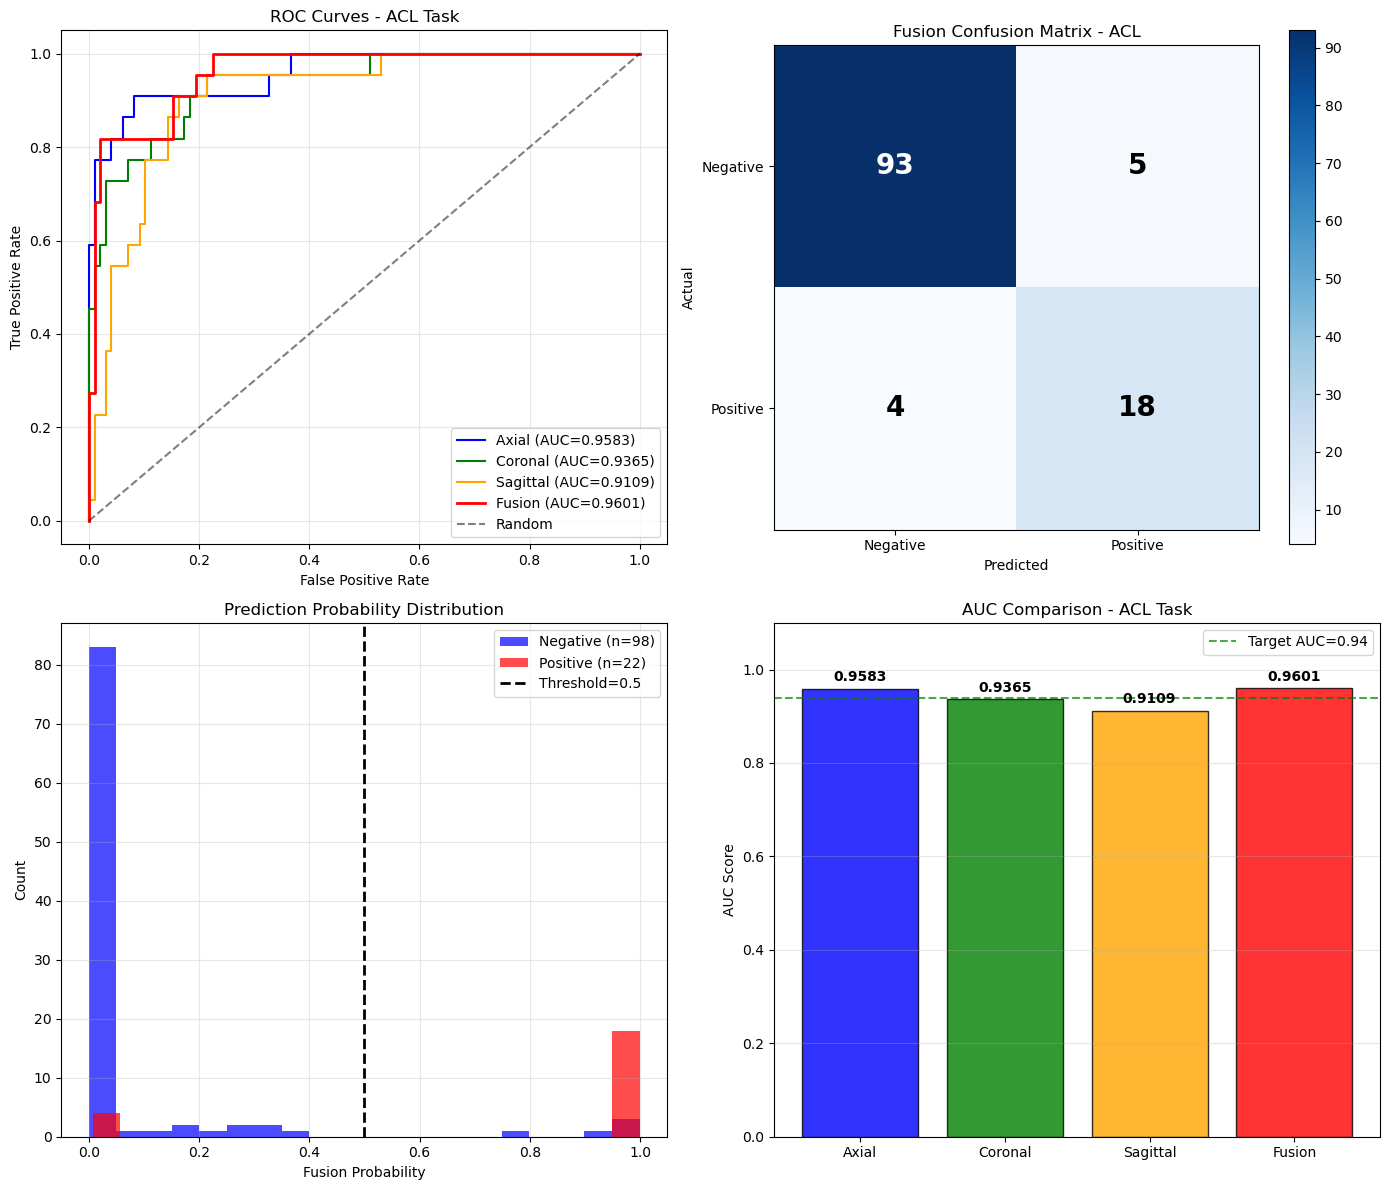


Plots saved to: runs_mrnet_hybrid_fusion_npy\evaluation_plots_acl.png


In [17]:
# 13) Visualization: ROC Curves, Confusion Matrix, and Prediction Distribution
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# === Plot 1: ROC Curves for Each Plane and Fusion ===
ax1 = axes[0, 0]
colors = {'axial': 'blue', 'coronal': 'green', 'sagittal': 'orange', 'fusion': 'red'}

for plane in PLANES:
	logits = valid_df[f"logit_{plane}"].to_numpy()
	probs = 1.0 / (1.0 + np.exp(-logits))
	fpr, tpr, _ = roc_curve(y_valid, probs)
	auc_val = auc(fpr, tpr)
	ax1.plot(fpr, tpr, color=colors[plane], label=f'{plane.capitalize()} (AUC={auc_val:.4f})')

# Fusion ROC
fpr_fusion, tpr_fusion, _ = roc_curve(y_valid, p_valid)
auc_fusion_val = auc(fpr_fusion, tpr_fusion)
ax1.plot(fpr_fusion, tpr_fusion, color=colors['fusion'], linewidth=2, 
		 label=f'Fusion (AUC={auc_fusion_val:.4f})')

ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title(f'ROC Curves - {TASK.upper()} Task')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

# === Plot 2: Confusion Matrix Heatmap ===
ax2 = axes[0, 1]
cm = confusion_matrix(y_valid, pred_valid)
im = ax2.imshow(cm, cmap='Blues')
ax2.set_xticks([0, 1])
ax2.set_yticks([0, 1])
ax2.set_xticklabels(['Negative', 'Positive'])
ax2.set_yticklabels(['Negative', 'Positive'])
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')
ax2.set_title(f'Fusion Confusion Matrix - {TASK.upper()}')

# Add text annotations
for i in range(2):
	for j in range(2):
		ax2.text(j, i, str(cm[i, j]), ha='center', va='center', 
				fontsize=20, fontweight='bold', color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.colorbar(im, ax=ax2)

# === Plot 3: Prediction Probability Distribution ===
ax3 = axes[1, 0]
neg_probs = p_valid[y_valid == 0]
pos_probs = p_valid[y_valid == 1]

ax3.hist(neg_probs, bins=20, alpha=0.7, label=f'Negative (n={len(neg_probs)})', color='blue')
ax3.hist(pos_probs, bins=20, alpha=0.7, label=f'Positive (n={len(pos_probs)})', color='red')
ax3.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Threshold=0.5')
ax3.set_xlabel('Fusion Probability')
ax3.set_ylabel('Count')
ax3.set_title('Prediction Probability Distribution')
ax3.legend()
ax3.grid(True, alpha=0.3)

# === Plot 4: Plane Logits Comparison ===
ax4 = axes[1, 1]
plane_aucs = []
for plane in PLANES:
	logits = valid_df[f"logit_{plane}"].to_numpy()
	probs = 1.0 / (1.0 + np.exp(-logits))
	auc_val = roc_auc_score(y_valid, probs)
	plane_aucs.append(auc_val)
plane_aucs.append(auc_fusion_val)

bar_labels = [p.capitalize() for p in PLANES] + ['Fusion']
bar_colors = [colors[p] for p in PLANES] + [colors['fusion']]
bars = ax4.bar(bar_labels, plane_aucs, color=bar_colors, alpha=0.8, edgecolor='black')

for bar, auc_val in zip(bars, plane_aucs):
	ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
			f'{auc_val:.4f}', ha='center', va='bottom', fontweight='bold')

ax4.set_ylabel('AUC Score')
ax4.set_title(f'AUC Comparison - {TASK.upper()} Task')
ax4.set_ylim(0, 1.1)
ax4.axhline(y=0.94, color='green', linestyle='--', alpha=0.7, label='Target AUC=0.94')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(RUNS_DIR / f'evaluation_plots_{TASK}.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPlots saved to: {RUNS_DIR / f'evaluation_plots_{TASK}.png'}")

# 14) FINAL TEST SET EVALUATION (HELD OUT)

⚠️ **IMPORTANT**: This section evaluates the model on the **held-out test set** (original validation data).
- This test set was **NEVER seen during training or validation**
- Run this **ONLY ONCE** after all model development is complete
- Results here represent the true generalization performance

In [18]:
# 14a) Generate Test Set Logits (HELD OUT - Original Valid Folder)
# ============================================================
# ⚠️ WARNING: Run this ONLY for final evaluation!
# This test set was NEVER seen during training or model selection.
# ============================================================

def collect_test_logits_for_plane(plane: str, ckpt_path: Path) -> pd.DataFrame:
    """
    Collect logits for TEST SET (held-out original validation data).
    
    Test data comes from original 'valid' folder.
    """
    model = load_hybrid_expert(ckpt_path)
    rows = []
    
    ds = PlaneNPYDataset(
        test_index, DATA_ROOT, 
        logical_split="test", 
        data_folder="valid",  # Test data is in original 'valid' folder!
        plane=plane, 
        target_slices=TARGET_SLICES, 
        transform=valid_tf, 
        seed=SEED
    )
    loader = DataLoader(ds, batch_size=int(HYPER["valid_batch"]), shuffle=False, 
                       num_workers=0, pin_memory=bool(HYPER["pin_memory"]))
    
    for x, y, eid in tqdm(loader, desc=f"TEST logits {plane}", leave=False):
        x = x.to(device, non_blocking=True)
        with autocast_ctx():
            logit = model(x)
        logit = logit.detach().cpu().numpy()
        for i in range(len(eid)):
            rows.append({
                "split": "test", 
                "exam_id": str(eid[i]), 
                "y": float(y[i].item()), 
                f"logit_{plane}": float(logit[i])
            })
    
    return pd.DataFrame(rows)

print("="*60)
print("🔒 GENERATING TEST SET LOGITS (HELD OUT)")
print("="*60)
print(f"Test set size: {len(test_index)} exams")
print("⚠️  This data was NEVER seen during training!")
print("="*60)

test_logits = []
for plane in PLANES:
    dfp = collect_test_logits_for_plane(plane, expert_ckpts[plane])
    test_logits.append(dfp)

# Merge logits across planes
test_scores = test_logits[0]
for dfp in test_logits[1:]:
    test_scores = test_scores.merge(dfp, on=["split", "exam_id", "y"], how="inner")

test_scores_path = RUNS_DIR / f"test_logits_{TASK}.csv"
test_scores.to_csv(test_scores_path, index=False)
print(f"\n✅ Saved test logits: {test_scores_path}")
print(f"   Test samples: {len(test_scores)}")
test_scores.head()

🔒 GENERATING TEST SET LOGITS (HELD OUT)
Test set size: 120 exams
⚠️  This data was NEVER seen during training!


C:\Users\ganee\AppData\Local\Temp\ipykernel_14968\4134133889.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location="cpu")


HybridPlaneExpert: densenet121 (1024) + CustomCNN (256) = 1280
Loaded expert for axial | Best AUC: 0.9583


TEST logits axial:   0%|          | 0/60 [00:00<?, ?it/s]C:\Users\ganee\AppData\Local\Temp\ipykernel_14968\3130343012.py:56: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  autocast_ctx = lambda: torch.cuda.amp.autocast(enabled=use_amp)


HybridPlaneExpert: densenet121 (1024) + CustomCNN (256) = 1280
Loaded expert for coronal | Best AUC: 0.9365


HybridPlaneExpert: densenet121 (1024) + CustomCNN (256) = 1280
Loaded expert for sagittal | Best AUC: 0.9109



✅ Saved test logits: runs_mrnet_hybrid_fusion_npy\test_logits_acl.csv
   Test samples: 120


,split,exam_id,y,logit_axial,logit_coronal,logit_sagittal
0,test,1130,0.0,-5.039062,-4.425781,-3.591797
1,test,1131,0.0,-4.046875,-4.941406,-3.121094
2,test,1132,0.0,-3.998047,-4.597656,-3.232422
3,test,1133,0.0,-4.441406,-4.554688,-3.417969
4,test,1134,0.0,-2.792969,-2.718750,-3.017578


In [19]:
# 14b) Evaluate Fusion Model on Test Set
# ============================================================
# Final evaluation on held-out test data
# ============================================================

# Prepare test features
X_test = test_scores[feat_cols].to_numpy(dtype=np.float32)
y_test = test_scores["y"].to_numpy(dtype=np.int64)

# Get predictions from trained fusion model
p_test = fusion.predict_proba(X_test)[:, 1]
pred_test = (p_test >= 0.5).astype(np.int64)

# Calculate metrics
auc_test = roc_auc_score(y_test, p_test) if len(np.unique(y_test)) > 1 else float("nan")
acc_test = accuracy_score(y_test, pred_test)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, pred_test, average='binary')

print("="*60)
print("🔒 FINAL TEST SET RESULTS (HELD OUT)")
print("="*60)
print(f"\n📊 FUSION MODEL PERFORMANCE:")
print(f"   Test AUC:       {auc_test:.4f}")
print(f"   Test Accuracy:  {acc_test:.4f}")
print(f"   Test Precision: {precision:.4f}")
print(f"   Test Recall:    {recall:.4f}")
print(f"   Test F1-Score:  {f1:.4f}")

# Per-plane AUC on test set
print(f"\n📊 PER-PLANE TEST AUC:")
for plane in PLANES:
    logits = test_scores[f"logit_{plane}"].to_numpy()
    probs = 1.0 / (1.0 + np.exp(-logits))
    plane_auc = roc_auc_score(y_test, probs) if len(np.unique(y_test)) > 1 else float("nan")
    print(f"   {plane.capitalize():10s}: {plane_auc:.4f}")

# Confusion Matrix
cm_test = confusion_matrix(y_test, pred_test)
print(f"\n📊 TEST CONFUSION MATRIX:")
print(f"   TN={cm_test[0,0]:3d}  FP={cm_test[0,1]:3d}")
print(f"   FN={cm_test[1,0]:3d}  TP={cm_test[1,1]:3d}")

print("="*60)
print("⚠️  These results are from data NEVER seen during training!")
print("="*60)

🔒 FINAL TEST SET RESULTS (HELD OUT)

📊 FUSION MODEL PERFORMANCE:
   Test AUC:       0.9537
   Test Accuracy:  0.9250
   Test Precision: 0.9245
   Test Recall:    0.9074
   Test F1-Score:  0.9159

📊 PER-PLANE TEST AUC:
   Axial     : 0.9369
   Coronal   : 0.9341
   Sagittal  : 0.9338

📊 TEST CONFUSION MATRIX:
   TN= 62  FP=  4
   FN=  5  TP= 49
⚠️  These results are from data NEVER seen during training!


C:\Users\ganee\AppData\Local\Temp\ipykernel_14968\1085405760.py:103: UserWarning: Glyph 128274 (\N{LOCK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ganee\AppData\Local\Temp\ipykernel_14968\1085405760.py:104: UserWarning: Glyph 128274 (\N{LOCK}) missing from font(s) DejaVu Sans.
  plt.savefig(RUNS_DIR / f'test_evaluation_{TASK}.png', dpi=150, bbox_inches='tight')
c:\Users\ganee\.conda\envs\gpu\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128274 (\N{LOCK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


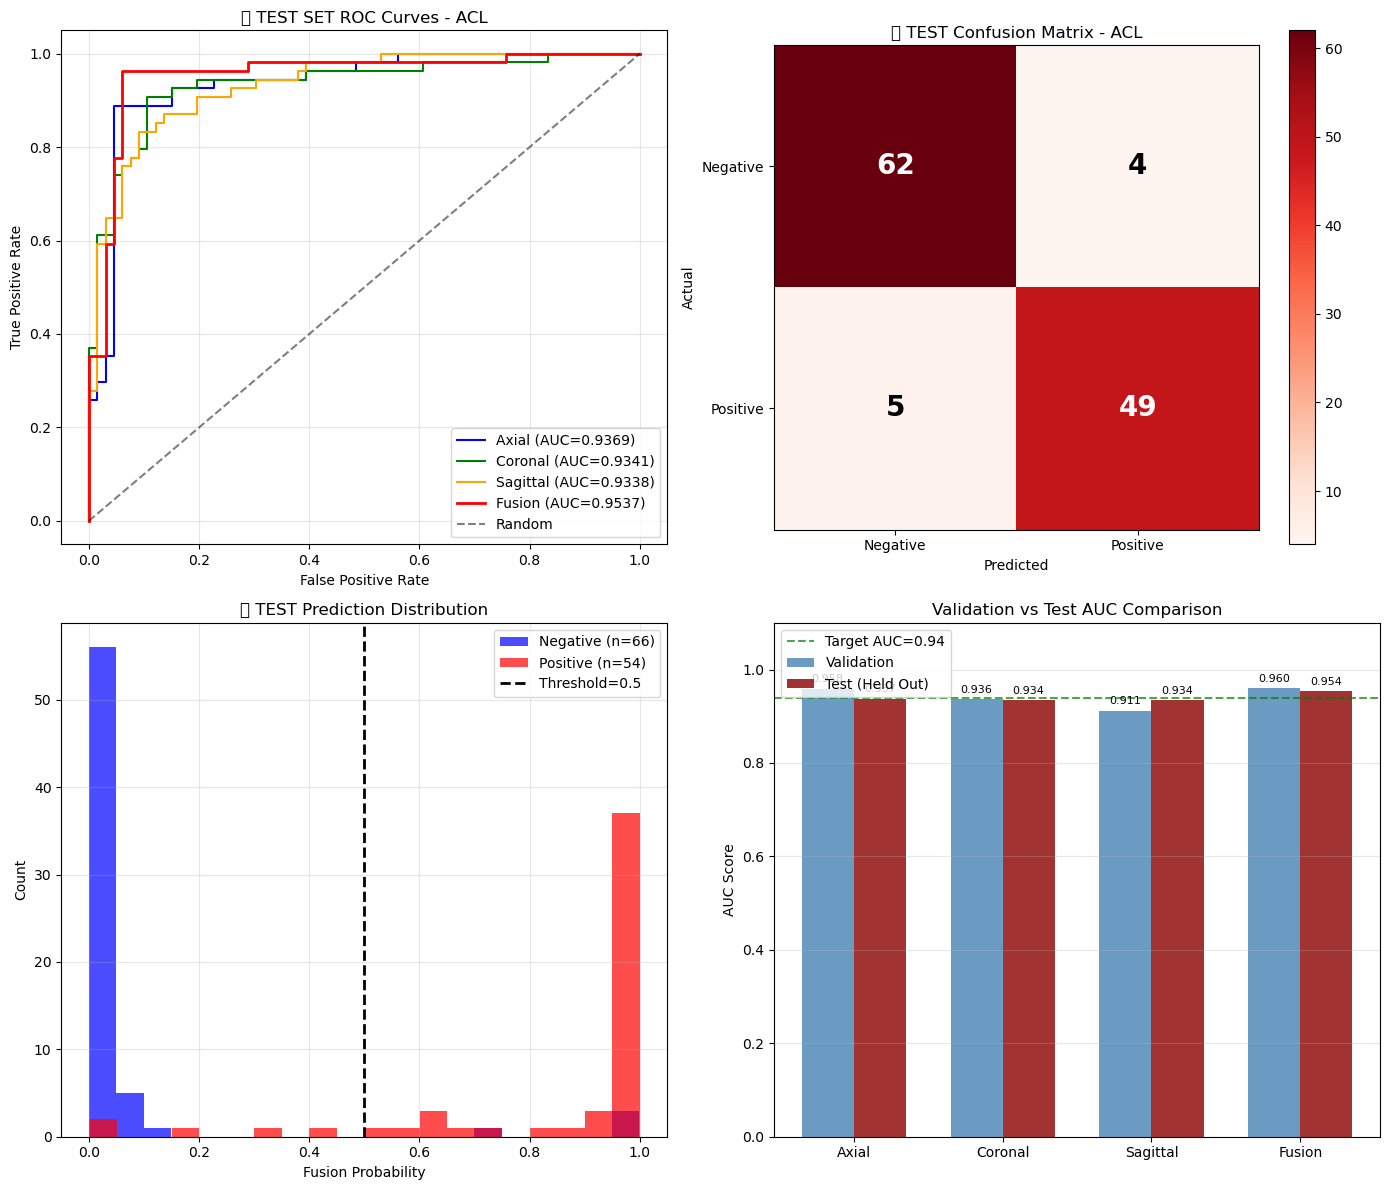


✅ Test evaluation plots saved to: runs_mrnet_hybrid_fusion_npy\test_evaluation_acl.png


In [20]:
# 14c) Visualization: Test Set Results
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# === Plot 1: Test ROC Curves ===
ax1 = axes[0, 0]
colors = {'axial': 'blue', 'coronal': 'green', 'sagittal': 'orange', 'fusion': 'red'}

for plane in PLANES:
    logits = test_scores[f"logit_{plane}"].to_numpy()
    probs = 1.0 / (1.0 + np.exp(-logits))
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_val = auc(fpr, tpr)
    ax1.plot(fpr, tpr, color=colors[plane], label=f'{plane.capitalize()} (AUC={auc_val:.4f})')

# Fusion ROC
fpr_test, tpr_test, _ = roc_curve(y_test, p_test)
auc_test_val = auc(fpr_test, tpr_test)
ax1.plot(fpr_test, tpr_test, color=colors['fusion'], linewidth=2, 
         label=f'Fusion (AUC={auc_test_val:.4f})')

ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title(f'🔒 TEST SET ROC Curves - {TASK.upper()}')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

# === Plot 2: Test Confusion Matrix ===
ax2 = axes[0, 1]
im = ax2.imshow(cm_test, cmap='Reds')
ax2.set_xticks([0, 1])
ax2.set_yticks([0, 1])
ax2.set_xticklabels(['Negative', 'Positive'])
ax2.set_yticklabels(['Negative', 'Positive'])
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')
ax2.set_title(f'🔒 TEST Confusion Matrix - {TASK.upper()}')

for i in range(2):
    for j in range(2):
        ax2.text(j, i, str(cm_test[i, j]), ha='center', va='center', 
                fontsize=20, fontweight='bold', color='white' if cm_test[i, j] > cm_test.max()/2 else 'black')
plt.colorbar(im, ax=ax2)

# === Plot 3: Test Prediction Distribution ===
ax3 = axes[1, 0]
neg_probs_test = p_test[y_test == 0]
pos_probs_test = p_test[y_test == 1]

ax3.hist(neg_probs_test, bins=20, alpha=0.7, label=f'Negative (n={len(neg_probs_test)})', color='blue')
ax3.hist(pos_probs_test, bins=20, alpha=0.7, label=f'Positive (n={len(pos_probs_test)})', color='red')
ax3.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Threshold=0.5')
ax3.set_xlabel('Fusion Probability')
ax3.set_ylabel('Count')
ax3.set_title('🔒 TEST Prediction Distribution')
ax3.legend()
ax3.grid(True, alpha=0.3)

# === Plot 4: Validation vs Test AUC Comparison ===
ax4 = axes[1, 1]

# Collect AUCs for both sets
val_aucs = []
test_aucs = []
for plane in PLANES:
    # Validation AUC
    val_logits = valid_df[f"logit_{plane}"].to_numpy()
    val_probs = 1.0 / (1.0 + np.exp(-val_logits))
    val_aucs.append(roc_auc_score(y_valid, val_probs))
    
    # Test AUC
    test_logits = test_scores[f"logit_{plane}"].to_numpy()
    test_probs = 1.0 / (1.0 + np.exp(-test_logits))
    test_aucs.append(roc_auc_score(y_test, test_probs))

val_aucs.append(auc_fusion_val)  # Validation fusion
test_aucs.append(auc_test_val)   # Test fusion

x_pos = np.arange(len(PLANES) + 1)
width = 0.35

bars1 = ax4.bar(x_pos - width/2, val_aucs, width, label='Validation', color='steelblue', alpha=0.8)
bars2 = ax4.bar(x_pos + width/2, test_aucs, width, label='Test (Held Out)', color='darkred', alpha=0.8)

ax4.set_ylabel('AUC Score')
ax4.set_title('Validation vs Test AUC Comparison')
ax4.set_xticks(x_pos)
ax4.set_xticklabels([p.capitalize() for p in PLANES] + ['Fusion'])
ax4.set_ylim(0, 1.1)
ax4.axhline(y=0.94, color='green', linestyle='--', alpha=0.7, label='Target AUC=0.94')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(RUNS_DIR / f'test_evaluation_{TASK}.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Test evaluation plots saved to: {RUNS_DIR / f'test_evaluation_{TASK}.png'}")

In [21]:
# 14d) Final Summary Report
# ============================================================

print("="*70)
print("📋 FINAL MODEL EVALUATION SUMMARY")
print("="*70)

print("\n📁 DATA SPLIT:")
print(f"   Training Set:   {len(new_train_index):4d} exams (from original train folder)")
print(f"   Validation Set: {len(new_valid_index):4d} exams (from original train folder)")
print(f"   Test Set:       {len(test_index):4d} exams (original valid folder - HELD OUT)")

print("\n" + "-"*70)
print("📊 VALIDATION SET RESULTS:")
print("-"*70)
print(f"   {'Metric':<15} {'Axial':>10} {'Coronal':>10} {'Sagittal':>10} {'Fusion':>10}")
print(f"   {'-'*15} {'-'*10} {'-'*10} {'-'*10} {'-'*10}")

# Validation metrics
val_metrics = {'AUC': val_aucs}
print(f"   {'AUC':<15}", end="")
for v in val_aucs:
    print(f" {v:>10.4f}", end="")
print()

print("\n" + "-"*70)
print("🔒 TEST SET RESULTS (HELD OUT - FINAL):")
print("-"*70)
print(f"   {'Metric':<15} {'Axial':>10} {'Coronal':>10} {'Sagittal':>10} {'Fusion':>10}")
print(f"   {'-'*15} {'-'*10} {'-'*10} {'-'*10} {'-'*10}")

# Test metrics
print(f"   {'AUC':<15}", end="")
for t in test_aucs:
    print(f" {t:>10.4f}", end="")
print()

print("\n" + "-"*70)
print("📈 FUSION MODEL TEST METRICS:")
print("-"*70)
print(f"   AUC:        {auc_test:.4f}")
print(f"   Accuracy:   {acc_test:.4f}")
print(f"   Precision:  {precision:.4f}")
print(f"   Recall:     {recall:.4f}")
print(f"   F1-Score:   {f1:.4f}")

print("\n" + "-"*70)
print("🎯 TARGET COMPARISON:")
print("-"*70)
target_auc = 0.94
print(f"   Target AUC:     {target_auc:.4f}")
print(f"   Achieved AUC:   {auc_test:.4f}")
print(f"   Difference:     {auc_test - target_auc:+.4f}")
if auc_test >= target_auc:
    print(f"   Status:         ✅ TARGET ACHIEVED!")
else:
    print(f"   Status:         ⚠️  Below target")

print("\n" + "="*70)
print("⚠️  REMINDER: Test results are from data NEVER seen during training!")
print("="*70)

📋 FINAL MODEL EVALUATION SUMMARY

📁 DATA SPLIT:
   Training Set:   1010 exams (from original train folder)
   Validation Set:  120 exams (from original train folder)
   Test Set:        120 exams (original valid folder - HELD OUT)

----------------------------------------------------------------------
📊 VALIDATION SET RESULTS:
----------------------------------------------------------------------
   Metric               Axial    Coronal   Sagittal     Fusion
   --------------- ---------- ---------- ---------- ----------
   AUC                 0.9583     0.9365     0.9109     0.9601

----------------------------------------------------------------------
🔒 TEST SET RESULTS (HELD OUT - FINAL):
----------------------------------------------------------------------
   Metric               Axial    Coronal   Sagittal     Fusion
   --------------- ---------- ---------- ---------- ----------
   AUC                 0.9369     0.9341     0.9338     0.9537

---------------------------------------

# 🎨 Conference-Ready Visualizations: Grad-CAM & Attention Maps

## Visualization Suite for ACL Tear Detection:
1. **Grad-CAM**: Class activation mapping to show where the model focuses
2. **CBAM Channel Attention**: Bar charts showing important feature channels
3. **CBAM Spatial Attention**: Heatmaps showing spatial focus regions
4. **Comparative Analysis**: Baseline vs Hybrid model visualizations
5. **Multi-plane Comparison**: Axial vs Coronal vs Sagittal focus patterns

## Implementation Steps:
- Install `pytorch-grad-cam` library
- Define Grad-CAM wrapper for HybridPlaneExpert
- Generate visualizations on test samples
- Create publication-ready figures with annotations

In [7]:
# 1) Install Required Libraries for Visualization
!pip install grad-cam matplotlib seaborn scikit-image -q

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle, FancyBboxPatch
from matplotlib.lines import Line2D
import cv2
from skimage import exposure
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import BinaryClassifierOutputTarget

# Set publication-ready plotting style
plt.style.use('seaborn-v0_8-paper')
sns.set_palette("husl")
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.titlesize': 13,
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial', 'Helvetica']
})

print("✅ Visualization libraries installed and configured!")
print("   - grad-cam: For class activation mapping")
print("   - matplotlib/seaborn: Publication-ready plots")
print("   - cv2/skimage: Image processing")

✅ Visualization libraries installed and configured!
   - grad-cam: For class activation mapping
   - matplotlib/seaborn: Publication-ready plots
   - cv2/skimage: Image processing


In [12]:
# 2) Grad-CAM Wrapper for HybridPlaneExpert Model

class HybridPlaneExpertGradCAM(nn.Module):
    """
    Wrapper for HybridPlaneExpert to enable Grad-CAM visualization.
    
    This wrapper:
    1. Processes a SINGLE slice (not entire volume)
    2. Exposes the target layer for gradient computation
    3. Returns the final classification logit
    
    Target layer options:
    - 'backbone': Last conv layer of pretrained backbone
    - 'cbam': After CBAM attention module
    - 'custom_cnn': Last conv layer of custom CNN
    """
    def __init__(self, expert_model: HybridPlaneExpert, target_layer_name: str = 'cbam'):
        super().__init__()
        self.expert = expert_model
        self.target_layer_name = target_layer_name
        
        # Identify target layer for Grad-CAM
        if target_layer_name == 'backbone':
            # Last conv layer of backbone
            if hasattr(self.expert.backbone, 'features'):
                # DenseNet/EfficientNet/AlexNet style
                self.target_layer = self.expert.backbone.features[-1]
            else:
                # ResNet style
                self.target_layer = self.expert.backbone[-1]
        elif target_layer_name == 'cbam':
            # After CBAM attention
            if hasattr(self.expert, 'cbam'):
                self.target_layer = self.expert.cbam
            else:
                raise ValueError("Model doesn't have CBAM module")
        elif target_layer_name == 'custom_cnn':
            # Last conv layer of custom CNN
            if hasattr(self.expert, 'custom_cnn'):
                # Find last conv layer in custom_cnn.features
                for layer in reversed(list(self.expert.custom_cnn.features)):
                    if isinstance(layer, nn.Conv2d):
                        self.target_layer = layer
                        break
            else:
                raise ValueError("Model doesn't have custom_cnn module")
        else:
            raise ValueError(f"Unknown target layer: {target_layer_name}")
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass for a SINGLE slice (batch of slices).
        
        Args:
            x: (B, C, H, W) - batch of slices
        Returns:
            logits: (B,) - classification logits
        """
        # Since we're processing single slices, we need to simulate the volume format
        # Add slice dimension: (B, C, H, W) -> (B, 1, C, H, W)
        x_volume = x.unsqueeze(1)
        
        # Forward through expert model
        logits = self.expert(x_volume)
        return logits
    
    def get_target_layer(self):
        """Return the target layer for Grad-CAM."""
        return self.target_layer


print("="*70)
print("Grad-CAM Wrapper for HybridPlaneExpert")
print("="*70)
print("\nTarget layer options:")
print("  - 'backbone': Last conv layer of pretrained backbone")
print("  - 'cbam': After CBAM attention module (RECOMMENDED)")
print("  - 'custom_cnn': Last conv layer of custom CNN")
print("\n💡 TIP: CBAM layer shows attention-enhanced features")
print("="*70)

Grad-CAM Wrapper for HybridPlaneExpert

Target layer options:
  - 'backbone': Last conv layer of pretrained backbone
  - 'cbam': After CBAM attention module (RECOMMENDED)
  - 'custom_cnn': Last conv layer of custom CNN

💡 TIP: CBAM layer shows attention-enhanced features


In [13]:
# 3) CBAM Attention Extraction Functions

def extract_channel_attention_weights(model: HybridPlaneExpert, input_slice: torch.Tensor) -> np.ndarray:
    """
    Extract channel attention weights from CBAM module.
    
    Args:
        model: HybridPlaneExpert model
        input_slice: (1, C, H, W) input slice
    
    Returns:
        channel_weights: (num_channels,) attention weights
    """
    if not hasattr(model, 'cbam'):
        raise ValueError("Model doesn't have CBAM module")
    
    model.eval()
    with torch.no_grad():
        # Forward through backbone
        x = model.backbone(input_slice)
        if model.config["backbone"] != "alexnet":
            x = F.relu(x)
        
        # Get channel attention weights
        b, c, h, w = x.size()
        avg_out = model.cbam.channel_attention.avg_pool(x).view(b, c)
        max_out = model.cbam.channel_attention.max_pool(x).view(b, c)
        
        avg_weight = model.cbam.channel_attention.fc(avg_out)
        max_weight = model.cbam.channel_attention.fc(max_out)
        
        channel_weights = torch.sigmoid(avg_weight + max_weight)
        
    return channel_weights.squeeze().cpu().numpy()


def extract_spatial_attention_map(model: HybridPlaneExpert, input_slice: torch.Tensor) -> np.ndarray:
    """
    Extract spatial attention map from CBAM module.
    
    Args:
        model: HybridPlaneExpert model
        input_slice: (1, C, H, W) input slice
    
    Returns:
        spatial_map: (H, W) attention map
    """
    if not hasattr(model, 'cbam'):
        raise ValueError("Model doesn't have CBAM module")
    
    model.eval()
    with torch.no_grad():
        # Forward through backbone and channel attention
        x = model.backbone(input_slice)
        if model.config["backbone"] != "alexnet":
            x = F.relu(x)
        x = model.cbam.channel_attention(x)
        
        # Get spatial attention map
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        combined = torch.cat([avg_out, max_out], dim=1)
        spatial_map = torch.sigmoid(model.cbam.spatial_attention.conv(combined))
        
    return spatial_map.squeeze().cpu().numpy()


def extract_slice_attention_weights(model: HybridPlaneExpert, input_volume: torch.Tensor) -> np.ndarray:
    """
    Extract slice attention weights for a volume.
    
    Args:
        model: HybridPlaneExpert model
        input_volume: (1, K, C, H, W) input volume
    
    Returns:
        slice_weights: (K,) attention weights for each slice
    """
    if not hasattr(model, 'slice_attention'):
        raise ValueError("Model doesn't have slice_attention module")
    
    model.eval()
    with torch.no_grad():
        # Encode all slices
        b, k, c, h, w = input_volume.shape
        x_flat = input_volume.view(b * k, c, h, w)
        slice_features = model.encode_slice(x_flat)  # (K, combined_dim)
        slice_features = slice_features.view(b, k, -1)  # (1, K, combined_dim)
        
        # Get attention weights
        _, attn_weights = model.slice_attention(slice_features[0])  # (K,)
        
    return attn_weights.cpu().numpy()


print("="*70)
print("CBAM Attention Extraction Functions")
print("="*70)
print("\n✅ extract_channel_attention_weights: Channel importance (num_channels,)")
print("✅ extract_spatial_attention_map: Spatial focus map (H, W)")
print("✅ extract_slice_attention_weights: Slice importance (K,)")
print("="*70)

CBAM Attention Extraction Functions

✅ extract_channel_attention_weights: Channel importance (num_channels,)
✅ extract_spatial_attention_map: Spatial focus map (H, W)
✅ extract_slice_attention_weights: Slice importance (K,)


In [14]:
# 4) Publication-Ready Grad-CAM Visualization Functions

def generate_gradcam_visualization(
    model: HybridPlaneExpert,
    input_slice: torch.Tensor,
    target_layer_name: str = 'cbam',
    class_idx: int = 1,
    colormap: int = cv2.COLORMAP_JET
) -> tuple:
    """
    Generate Grad-CAM heatmap for a single slice.
    
    Args:
        model: HybridPlaneExpert model
        input_slice: (C, H, W) input slice (normalized)
        target_layer_name: 'cbam', 'backbone', or 'custom_cnn'
        class_idx: Target class (1 for positive, 0 for negative)
        colormap: OpenCV colormap for visualization
    
    Returns:
        (original_img, cam_heatmap, overlaid_img, confidence_score)
    """
    model.eval()
    device = next(model.parameters()).device
    
    # Prepare input (add batch dimension)
    input_batch = input_slice.unsqueeze(0).to(device)  # (1, C, H, W)
    
    # Create Grad-CAM wrapper
    wrapper = HybridPlaneExpertGradCAM(model, target_layer_name)
    target_layer = wrapper.get_target_layer()
    
    # Initialize Grad-CAM
    cam = GradCAM(model=wrapper, target_layers=[target_layer])
    
    # Generate CAM
    targets = [BinaryClassifierOutputTarget(class_idx)]
    grayscale_cam = cam(input_tensor=input_batch, targets=targets)[0]
    
    # Get prediction confidence
    with torch.no_grad():
        logit = wrapper(input_batch)
        confidence = torch.sigmoid(logit).item()
    
    # Convert input to RGB numpy array (0-1 range)
    img_rgb = input_slice.permute(1, 2, 0).cpu().numpy()
    
    # Normalize to 0-1 range for visualization
    img_rgb = (img_rgb - img_rgb.min()) / (img_rgb.max() - img_rgb.min() + 1e-8)
    
    # Ensure 3 channels
    if img_rgb.shape[-1] == 1:
        img_rgb = np.repeat(img_rgb, 3, axis=-1)
    
    # Create CAM overlay
    cam_overlay = show_cam_on_image(img_rgb, grayscale_cam, use_rgb=True, 
                                     colormap=colormap, image_weight=0.5)
    
    return img_rgb, grayscale_cam, cam_overlay, confidence


def plot_single_gradcam(
    original_img: np.ndarray,
    cam_heatmap: np.ndarray,
    cam_overlay: np.ndarray,
    confidence: float,
    true_label: int,
    title: str = "Grad-CAM Visualization",
    save_path: Path = None,
    annotations: list = None
):
    """
    Create publication-ready 3-panel Grad-CAM figure.
    
    Args:
        original_img: (H, W, 3) original image
        cam_heatmap: (H, W) CAM heatmap
        cam_overlay: (H, W, 3) overlaid image
        confidence: Model confidence score
        true_label: Ground truth label
        title: Figure title
        save_path: Path to save figure
        annotations: List of (x, y, text) tuples for annotations
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Panel 1: Original Image
    axes[0].imshow(original_img, cmap='gray')
    axes[0].set_title("Original MRI Slice", fontweight='bold')
    axes[0].axis('off')
    
    # Panel 2: CAM Heatmap
    im = axes[1].imshow(cam_heatmap, cmap='jet', vmin=0, vmax=1)
    axes[1].set_title("Grad-CAM Heatmap", fontweight='bold')
    axes[1].axis('off')
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    cbar.set_label('Attention Weight', rotation=270, labelpad=15)
    
    # Panel 3: Overlay with annotations
    axes[2].imshow(cam_overlay)
    axes[2].set_title("Overlay with Focus Regions", fontweight='bold')
    axes[2].axis('off')
    
    # Add annotations if provided
    if annotations:
        for x, y, text in annotations:
            axes[2].annotate(
                text, xy=(x, y), xytext=(x+20, y-20),
                bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.7),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', 
                               color='red', lw=2),
                fontsize=10, fontweight='bold', color='red'
            )
    
    # Add prediction info
    pred_class = "Positive" if confidence > 0.5 else "Negative"
    true_class = "Positive" if true_label == 1 else "Negative"
    correct = "✓" if (confidence > 0.5) == (true_label == 1) else "✗"
    
    info_text = (f"Prediction: {pred_class} ({confidence:.3f}) {correct}\n"
                 f"Ground Truth: {true_class}")
    
    fig.text(0.5, 0.02, info_text, ha='center', fontsize=11, 
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.suptitle(title, fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0.05, 1, 0.96])
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"   Saved: {save_path}")
    
    plt.show()


print("="*70)
print("Grad-CAM Visualization Functions")
print("="*70)
print("\n✅ generate_gradcam_visualization: Generate CAM for a slice")
print("✅ plot_single_gradcam: Publication-ready 3-panel figure")
print("="*70)

Grad-CAM Visualization Functions

✅ generate_gradcam_visualization: Generate CAM for a slice
✅ plot_single_gradcam: Publication-ready 3-panel figure


In [15]:
# 5) CBAM Attention Visualization Functions

def plot_channel_attention_bar(
    channel_weights: np.ndarray,
    top_k: int = 20,
    title: str = "CBAM Channel Attention",
    save_path: Path = None
):
    """
    Plot top-K channel attention weights as bar chart.
    
    Args:
        channel_weights: (num_channels,) channel attention weights
        top_k: Number of top channels to display
        title: Plot title
        save_path: Path to save figure
    """
    # Get top-K channels
    top_indices = np.argsort(channel_weights)[-top_k:][::-1]
    top_weights = channel_weights[top_indices]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Create bar chart with gradient colors
    colors = plt.cm.viridis(np.linspace(0.3, 0.9, top_k))
    bars = ax.barh(range(top_k), top_weights, color=colors, edgecolor='black', linewidth=0.5)
    
    # Customize
    ax.set_yticks(range(top_k))
    ax.set_yticklabels([f"Ch {idx}" for idx in top_indices])
    ax.set_xlabel("Attention Weight", fontweight='bold', fontsize=11)
    ax.set_ylabel("Feature Channel", fontweight='bold', fontsize=11)
    ax.set_title(title, fontweight='bold', fontsize=13, pad=15)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.set_xlim(0, max(top_weights) * 1.1)
    
    # Add value labels on bars
    for i, (bar, weight) in enumerate(zip(bars, top_weights)):
        ax.text(weight + 0.01, bar.get_y() + bar.get_height()/2, 
                f'{weight:.3f}', va='center', ha='left', fontsize=8)
    
    # Add statistics box
    stats_text = (f"Total Channels: {len(channel_weights)}\n"
                 f"Max Weight: {channel_weights.max():.3f}\n"
                 f"Mean Weight: {channel_weights.mean():.3f}\n"
                 f"Std Weight: {channel_weights.std():.3f}")
    ax.text(0.98, 0.02, stats_text, transform=ax.transAxes,
            fontsize=9, verticalalignment='bottom', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"   Saved: {save_path}")
    
    plt.show()


def plot_spatial_attention_overlay(
    original_img: np.ndarray,
    spatial_map: np.ndarray,
    title: str = "CBAM Spatial Attention",
    save_path: Path = None,
    annotations: list = None
):
    """
    Plot spatial attention map overlay on original image.
    
    Args:
        original_img: (H, W, 3) original image
        spatial_map: (H, W) spatial attention map
        title: Plot title
        save_path: Path to save figure
        annotations: List of (x, y, text) tuples
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Panel 1: Original Image
    axes[0].imshow(original_img, cmap='gray')
    axes[0].set_title("Original MRI Slice", fontweight='bold')
    axes[0].axis('off')
    
    # Panel 2: Spatial Attention Map
    im = axes[1].imshow(spatial_map, cmap='hot', vmin=0, vmax=1)
    axes[1].set_title("Spatial Attention Map", fontweight='bold')
    axes[1].axis('off')
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    cbar.set_label('Spatial Weight', rotation=270, labelpad=15)
    
    # Panel 3: Overlay
    # Resize spatial map to match image size if needed
    if spatial_map.shape != original_img.shape[:2]:
        from skimage.transform import resize
        spatial_map_resized = resize(spatial_map, original_img.shape[:2], 
                                     mode='reflect', anti_aliasing=True)
    else:
        spatial_map_resized = spatial_map
    
    # Create overlay
    overlay = original_img.copy()
    if len(overlay.shape) == 2:
        overlay = np.stack([overlay] * 3, axis=-1)
    
    # Apply spatial attention as color overlay
    heatmap_colored = plt.cm.hot(spatial_map_resized)[:, :, :3]
    overlay_combined = 0.5 * overlay + 0.5 * heatmap_colored
    
    axes[2].imshow(overlay_combined)
    axes[2].set_title("Overlay with Focus Regions", fontweight='bold')
    axes[2].axis('off')
    
    # Add annotations
    if annotations:
        for x, y, text in annotations:
            axes[2].annotate(
                text, xy=(x, y), xytext=(x+15, y-15),
                bbox=dict(boxstyle='round,pad=0.5', fc='cyan', alpha=0.7),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.2', 
                               color='blue', lw=2),
                fontsize=10, fontweight='bold', color='darkblue'
            )
    
    plt.suptitle(title, fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"   Saved: {save_path}")
    
    plt.show()


def plot_combined_attention_analysis(
    original_img: np.ndarray,
    cam_heatmap: np.ndarray,
    spatial_map: np.ndarray,
    slice_weights: np.ndarray,
    confidence: float,
    true_label: int,
    slice_idx: int,
    title: str = "Complete Attention Analysis",
    save_path: Path = None
):
    """
    Create comprehensive 4-panel attention analysis figure.
    
    Args:
        original_img: (H, W, 3) original image
        cam_heatmap: (H, W) Grad-CAM heatmap
        spatial_map: (H, W) CBAM spatial attention
        slice_weights: (K,) slice attention weights
        confidence: Model confidence
        true_label: Ground truth label
        slice_idx: Current slice index
        title: Figure title
        save_path: Path to save figure
    """
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)
    
    # Panel 1: Original
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.imshow(original_img, cmap='gray')
    ax1.set_title("Original MRI Slice", fontweight='bold', fontsize=12)
    ax1.axis('off')
    
    # Panel 2: Grad-CAM
    ax2 = fig.add_subplot(gs[0, 1])
    im2 = ax2.imshow(cam_heatmap, cmap='jet', vmin=0, vmax=1)
    ax2.set_title("Grad-CAM Heatmap\n(Class Activation)", fontweight='bold', fontsize=12)
    ax2.axis('off')
    plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
    
    # Panel 3: Spatial Attention
    ax3 = fig.add_subplot(gs[0, 2])
    im3 = ax3.imshow(spatial_map, cmap='hot', vmin=0, vmax=1)
    ax3.set_title("CBAM Spatial Attention\n(Where to Look)", fontweight='bold', fontsize=12)
    ax3.axis('off')
    plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)
    
    # Panel 4: Slice Attention Weights
    ax4 = fig.add_subplot(gs[1, :2])
    slice_indices = np.arange(len(slice_weights))
    colors = ['red' if i == slice_idx else 'steelblue' for i in slice_indices]
    bars = ax4.bar(slice_indices, slice_weights, color=colors, alpha=0.7, edgecolor='black')
    ax4.axvline(slice_idx, color='red', linestyle='--', linewidth=2, label='Current Slice')
    ax4.set_xlabel("Slice Index", fontweight='bold', fontsize=11)
    ax4.set_ylabel("Attention Weight", fontweight='bold', fontsize=11)
    ax4.set_title("Slice-Level Attention Weights\n(Which Slices Matter)", fontweight='bold', fontsize=12)
    ax4.grid(axis='y', alpha=0.3, linestyle='--')
    ax4.legend(fontsize=9)
    
    # Panel 5: Prediction Statistics
    ax5 = fig.add_subplot(gs[1, 2])
    ax5.axis('off')
    
    pred_class = "Positive" if confidence > 0.5 else "Negative"
    true_class = "Positive" if true_label == 1 else "Negative"
    correct = "✓ Correct" if (confidence > 0.5) == (true_label == 1) else "✗ Incorrect"
    
    stats_text = f"""
PREDICTION SUMMARY
{'='*30}

Predicted Class: {pred_class}
Confidence: {confidence:.4f}

Ground Truth: {true_class}
Result: {correct}

{'='*30}
ATTENTION METRICS

Current Slice: {slice_idx}/{len(slice_weights)-1}
Slice Importance: {slice_weights[slice_idx]:.4f}

Max Grad-CAM: {cam_heatmap.max():.3f}
Avg Grad-CAM: {cam_heatmap.mean():.3f}

Max Spatial Attn: {spatial_map.max():.3f}
Avg Spatial Attn: {spatial_map.mean():.3f}
    """
    
    ax5.text(0.1, 0.5, stats_text, fontsize=10, family='monospace',
             verticalalignment='center',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
    
    plt.suptitle(title, fontsize=15, fontweight='bold', y=0.98)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"   Saved: {save_path}")
    
    plt.show()


print("="*70)
print("CBAM Attention Visualization Functions")
print("="*70)
print("\n✅ plot_channel_attention_bar: Top-K channel importance")
print("✅ plot_spatial_attention_overlay: Spatial focus regions")
print("✅ plot_combined_attention_analysis: Comprehensive 4-panel figure")
print("="*70)

CBAM Attention Visualization Functions

✅ plot_channel_attention_bar: Top-K channel importance
✅ plot_spatial_attention_overlay: Spatial focus regions
✅ plot_combined_attention_analysis: Comprehensive 4-panel figure


In [16]:
# 6) Comparative Visualization Functions (Multi-Plane, Baseline vs Hybrid)

def plot_multiplane_comparison(
    samples_dict: dict,
    save_path: Path = None
):
    """
    Compare Grad-CAM heatmaps across three planes (axial, coronal, sagittal).
    
    Args:
        samples_dict: {
            'axial': (img, cam, confidence),
            'coronal': (img, cam, confidence),
            'sagittal': (img, cam, confidence)
        }
        save_path: Path to save figure
    """
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    planes = ['axial', 'coronal', 'sagittal']
    
    for col, plane in enumerate(planes):
        if plane not in samples_dict:
            continue
        
        img, cam, conf = samples_dict[plane]
        
        # Row 1: Original images
        axes[0, col].imshow(img, cmap='gray')
        axes[0, col].set_title(f"{plane.capitalize()} View", fontweight='bold', fontsize=12)
        axes[0, col].axis('off')
        
        # Row 2: Grad-CAM heatmaps
        im = axes[1, col].imshow(cam, cmap='jet', vmin=0, vmax=1)
        axes[1, col].set_title(f"Grad-CAM (Conf: {conf:.3f})", fontweight='bold', fontsize=11)
        axes[1, col].axis('off')
        
        # Add colorbar to last column
        if col == 2:
            plt.colorbar(im, ax=axes[1, col], fraction=0.046, pad=0.04)
    
    plt.suptitle("Multi-Plane Grad-CAM Comparison", fontsize=15, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"   Saved: {save_path}")
    
    plt.show()


def plot_baseline_vs_hybrid_comparison(
    original_img: np.ndarray,
    baseline_cam: np.ndarray,
    hybrid_cam: np.ndarray,
    baseline_conf: float,
    hybrid_conf: float,
    true_label: int,
    title: str = "Baseline vs Hybrid Model Comparison",
    save_path: Path = None
):
    """
    Compare Grad-CAM heatmaps between baseline and hybrid models.
    
    Args:
        original_img: (H, W, 3) original image
        baseline_cam: (H, W) baseline model CAM
        hybrid_cam: (H, W) hybrid model CAM
        baseline_conf: Baseline confidence
        hybrid_conf: Hybrid confidence
        true_label: Ground truth label
        title: Figure title
        save_path: Path to save figure
    """
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Row 1: Baseline Model
    axes[0, 0].imshow(original_img, cmap='gray')
    axes[0, 0].set_title("Original Image", fontweight='bold')
    axes[0, 0].axis('off')
    
    im1 = axes[0, 1].imshow(baseline_cam, cmap='jet', vmin=0, vmax=1)
    axes[0, 1].set_title(f"Baseline Model CAM\n(Conf: {baseline_conf:.3f})", fontweight='bold')
    axes[0, 1].axis('off')
    plt.colorbar(im1, ax=axes[0, 1], fraction=0.046, pad=0.04)
    
    # Baseline overlay
    baseline_overlay = show_cam_on_image(original_img, baseline_cam, use_rgb=True)
    axes[0, 2].imshow(baseline_overlay)
    axes[0, 2].set_title("Baseline Overlay", fontweight='bold')
    axes[0, 2].axis('off')
    
    # Row 2: Hybrid Model
    axes[1, 0].imshow(original_img, cmap='gray')
    axes[1, 0].set_title("Original Image", fontweight='bold')
    axes[1, 0].axis('off')
    
    im2 = axes[1, 1].imshow(hybrid_cam, cmap='jet', vmin=0, vmax=1)
    axes[1, 1].set_title(f"Hybrid Model CAM (CBAM)\n(Conf: {hybrid_conf:.3f})", fontweight='bold')
    axes[1, 1].axis('off')
    plt.colorbar(im2, ax=axes[1, 1], fraction=0.046, pad=0.04)
    
    # Hybrid overlay
    hybrid_overlay = show_cam_on_image(original_img, hybrid_cam, use_rgb=True)
    axes[1, 2].imshow(hybrid_overlay)
    axes[1, 2].set_title("Hybrid Overlay (Enhanced)", fontweight='bold')
    axes[1, 2].axis('off')
    
    # Add comparison text
    true_class = "Positive" if true_label == 1 else "Negative"
    baseline_correct = "✓" if (baseline_conf > 0.5) == (true_label == 1) else "✗"
    hybrid_correct = "✓" if (hybrid_conf > 0.5) == (true_label == 1) else "✗"
    
    comparison_text = f"""
Ground Truth: {true_class}

Baseline: {baseline_conf:.3f} {baseline_correct}
Hybrid: {hybrid_conf:.3f} {hybrid_correct}

Improvement: {abs(hybrid_conf - baseline_conf):.3f}
    """
    
    fig.text(0.5, 0.02, comparison_text, ha='center', fontsize=11, 
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5),
             family='monospace')
    
    plt.suptitle(title, fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0.05, 1, 0.96])
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"   Saved: {save_path}")
    
    plt.show()


def plot_positive_negative_comparison(
    positive_sample: tuple,
    negative_sample: tuple,
    task_name: str = "ACL",
    save_path: Path = None
):
    """
    Compare Grad-CAM patterns for positive vs negative cases.
    
    Args:
        positive_sample: (img, cam, confidence) for positive case
        negative_sample: (img, cam, confidence) for negative case
        task_name: Task name (e.g., "ACL", "Meniscus")
        save_path: Path to save figure
    """
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Positive case
    pos_img, pos_cam, pos_conf = positive_sample
    pos_overlay = show_cam_on_image(pos_img, pos_cam, use_rgb=True)
    
    axes[0, 0].imshow(pos_img, cmap='gray')
    axes[0, 0].set_title(f"Positive {task_name}\nOriginal", fontweight='bold', color='green')
    axes[0, 0].axis('off')
    
    im1 = axes[0, 1].imshow(pos_cam, cmap='jet', vmin=0, vmax=1)
    axes[0, 1].set_title(f"Grad-CAM\n(Conf: {pos_conf:.3f})", fontweight='bold', color='green')
    axes[0, 1].axis('off')
    plt.colorbar(im1, ax=axes[0, 1], fraction=0.046, pad=0.04)
    
    axes[0, 2].imshow(pos_overlay)
    axes[0, 2].set_title("Focus Regions\n(Pathology Detected)", fontweight='bold', color='green')
    axes[0, 2].axis('off')
    
    # Negative case
    neg_img, neg_cam, neg_conf = negative_sample
    neg_overlay = show_cam_on_image(neg_img, neg_cam, use_rgb=True)
    
    axes[1, 0].imshow(neg_img, cmap='gray')
    axes[1, 0].set_title(f"Negative {task_name}\nOriginal", fontweight='bold', color='red')
    axes[1, 0].axis('off')
    
    im2 = axes[1, 1].imshow(neg_cam, cmap='jet', vmin=0, vmax=1)
    axes[1, 1].set_title(f"Grad-CAM\n(Conf: {neg_conf:.3f})", fontweight='bold', color='red')
    axes[1, 1].axis('off')
    plt.colorbar(im2, ax=axes[1, 1], fraction=0.046, pad=0.04)
    
    axes[1, 2].imshow(neg_overlay)
    axes[1, 2].set_title("Focus Regions\n(No Pathology)", fontweight='bold', color='red')
    axes[1, 2].axis('off')
    
    plt.suptitle(f"Positive vs Negative Case Comparison: {task_name}", 
                 fontsize=15, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"   Saved: {save_path}")
    
    plt.show()


print("="*70)
print("Comparative Visualization Functions")
print("="*70)
print("\n✅ plot_multiplane_comparison: Compare axial/coronal/sagittal")
print("✅ plot_baseline_vs_hybrid_comparison: Baseline vs Hybrid model")
print("✅ plot_positive_negative_comparison: Positive vs Negative cases")
print("="*70)

Comparative Visualization Functions

✅ plot_multiplane_comparison: Compare axial/coronal/sagittal
✅ plot_baseline_vs_hybrid_comparison: Baseline vs Hybrid model
✅ plot_positive_negative_comparison: Positive vs Negative cases


## 🎯 Example: Generate Visualizations for Test Samples

Now let's apply these visualization functions to real test samples from your trained ACL model!

In [17]:
# 7) Load Trained Models and Prepare Test Data

# Create output directory for visualizations
viz_output_dir = RUNS_DIR / f"visualizations_{TASK}"
viz_output_dir.mkdir(parents=True, exist_ok=True)

print("="*70)
print(f"Loading Trained Models for Task: {TASK.upper()}")
print("="*70)

# Load trained models for all planes
trained_models = {}
for plane in PLANES:
    model_path = RUNS_DIR / f"hybrid_expert_{TASK}_{plane}.pt"
    
    if not model_path.exists():
        print(f"⚠️  Model not found: {model_path}")
        continue
    
    # Load checkpoint
    checkpoint = torch.load(model_path, map_location=device)
    
    # Reconstruct model
    model = HybridPlaneExpert(checkpoint["config"])
    model.load_state_dict(checkpoint["model_state"])
    model = model.to(device)
    model.eval()
    
    trained_models[plane] = {
        'model': model,
        'config': checkpoint["config"],
        'metrics': checkpoint.get("best_metrics", {})
    }
    
    print(f"✅ Loaded {plane.upper()} model:")
    print(f"   AUC: {checkpoint.get('best_metrics', {}).get('auc', 'N/A')}")
    print(f"   Accuracy: {checkpoint.get('best_metrics', {}).get('accuracy', 'N/A')}")

print("\n" + "="*70)
print(f"Visualization Output Directory: {viz_output_dir}")
print("="*70)

# Verify models are loaded
if len(trained_models) == 0:
    print("\n⚠️  WARNING: No trained models found!")
    print(f"   Expected location: {RUNS_DIR}")
    print("   Please run training first before generating visualizations.")
else:
    print(f"\n✅ Successfully loaded {len(trained_models)} plane expert models")

Loading Trained Models for Task: ACL


C:\Users\ganee\AppData\Local\Temp\ipykernel_16064\3976170764.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)


HybridPlaneExpert: densenet121 (1024) + CustomCNN (256) = 1280
✅ Loaded AXIAL model:
   AUC: N/A
   Accuracy: N/A
HybridPlaneExpert: densenet121 (1024) + CustomCNN (256) = 1280
✅ Loaded CORONAL model:
   AUC: N/A
   Accuracy: N/A
HybridPlaneExpert: densenet121 (1024) + CustomCNN (256) = 1280
✅ Loaded SAGITTAL model:
   AUC: N/A
   Accuracy: N/A

Visualization Output Directory: runs_mrnet_hybrid_fusion_npy\visualizations_acl

✅ Successfully loaded 3 plane expert models


In [27]:
# 8) Select Test Samples for Visualization (RANDOM Selection)

def select_visualization_samples(test_loader, plane: str, n_positive: int = 5, n_negative: int = 5, random_seed: int = None):
    """
    Randomly select test samples for visualization.
    
    Args:
        test_loader: Test data loader
        plane: Plane name (axial/coronal/sagittal)
        n_positive: Number of positive samples to select
        n_negative: Number of negative samples to select
        random_seed: Random seed for reproducibility (None = different samples each time)
    
    Returns:
        selected_samples: List of (volume, label, exam_id, slice_idx) tuples
    """
    model = trained_models[plane]['model']
    model.eval()
    
    all_positive_samples = []
    all_negative_samples = []
    
    print(f"\nCollecting all samples for {plane.upper()} plane...")
    
    # First pass: collect ALL positive and negative samples
    with torch.no_grad():
        for volumes, labels, exam_ids in test_loader:
            volumes = volumes.to(device)
            labels = labels.cpu().numpy()
            
            # Get predictions
            logits = model(volumes)
            confidences = torch.sigmoid(logits).cpu().numpy()
            
            # Store ALL samples
            for i in range(len(labels)):
                volume = volumes[i]
                label = int(labels[i])
                exam_id = exam_ids[i]
                confidence = float(confidences[i])
                
                # Get slice with highest attention (middle slice as proxy)
                middle_slice_idx = volume.shape[0] // 2
                
                sample_info = {
                    'volume': volume.cpu(),
                    'label': label,
                    'exam_id': exam_id,
                    'confidence': confidence,
                    'slice_idx': middle_slice_idx,
                    'plane': plane
                }
                
                if label == 1:
                    all_positive_samples.append(sample_info)
                else:
                    all_negative_samples.append(sample_info)
    
    print(f"   Found {len(all_positive_samples)} positive and {len(all_negative_samples)} negative samples")
    
    # Randomly select n_positive and n_negative samples
    if random_seed is not None:
        np.random.seed(random_seed)
        print(f"   Using random seed: {random_seed}")
    else:
        # Use truly random selection (different each time)
        np.random.seed(None)
        print(f"   Using random selection (different each time)")
    
    # Randomly select samples
    if len(all_positive_samples) >= n_positive:
        selected_indices = np.random.choice(len(all_positive_samples), size=n_positive, replace=False)
        positive_samples = [all_positive_samples[i] for i in selected_indices]
    else:
        positive_samples = all_positive_samples
        print(f"   ⚠️  Only {len(positive_samples)} positive samples available (requested {n_positive})")
    
    if len(all_negative_samples) >= n_negative:
        selected_indices = np.random.choice(len(all_negative_samples), size=n_negative, replace=False)
        negative_samples = [all_negative_samples[i] for i in selected_indices]
    else:
        negative_samples = all_negative_samples
        print(f"   ⚠️  Only {len(negative_samples)} negative samples available (requested {n_negative})")
    
    print(f"   ✅ Randomly selected {len(positive_samples)} positive, {len(negative_samples)} negative samples")
    
    return positive_samples, negative_samples


# Select samples for all available planes (if models are loaded)
if len(trained_models) > 0:
    selected_samples = {}
    
    # 🎲 RANDOM SELECTION: Set random_seed=None for different samples each time
    # Or set random_seed=42 (or any number) for reproducible results
    USE_RANDOM_SEED = None  # Change to 42 for reproducibility
    
    print("="*70)
    if USE_RANDOM_SEED is None:
        print("🎲 RANDOM SELECTION MODE: Selecting different samples each run")
    else:
        print(f"🔒 REPRODUCIBLE MODE: Using seed {USE_RANDOM_SEED}")
    print("="*70)
    
    for plane in trained_models.keys():
        # Create test loader for this plane
        test_loader = make_test_loader_for_plane(plane)
        
        # Select samples (RANDOMLY each time if USE_RANDOM_SEED=None)
        pos_samples, neg_samples = select_visualization_samples(
            test_loader, plane, 
            n_positive=3, n_negative=3,
            random_seed=USE_RANDOM_SEED
        )
        
        selected_samples[plane] = {
            'positive': pos_samples,
            'negative': neg_samples
        }
    
    print("\n" + "="*70)
    print("Sample Selection Complete!")
    print("="*70)
    for plane, samples in selected_samples.items():
        print(f"{plane.upper()}: {len(samples['positive'])} positive, {len(samples['negative'])} negative")
else:
    print("\n⚠️  Skipping sample selection - no models loaded")

🎲 RANDOM SELECTION MODE: Selecting different samples each run

   Found 54 positive and 66 negative samples
   Using random selection (different each time)
   ✅ Randomly selected 3 positive, 3 negative samples

   Found 54 positive and 66 negative samples
   Using random selection (different each time)
   ✅ Randomly selected 3 positive, 3 negative samples

   Found 54 positive and 66 negative samples
   Using random selection (different each time)
   ✅ Randomly selected 3 positive, 3 negative samples

Sample Selection Complete!
AXIAL: 3 positive, 3 negative
CORONAL: 3 positive, 3 negative
SAGITTAL: 3 positive, 3 negative


Generating Grad-CAM Visualizations

Generating visualization for AXIAL plane
   Exam ID: 1181
   Label: Positive
   Slice: 12/24

   Generating Grad-CAM...
   Creating publication-ready figure...
   Saved: runs_mrnet_hybrid_fusion_npy\visualizations_acl\gradcam_axial_1181_slice12.png


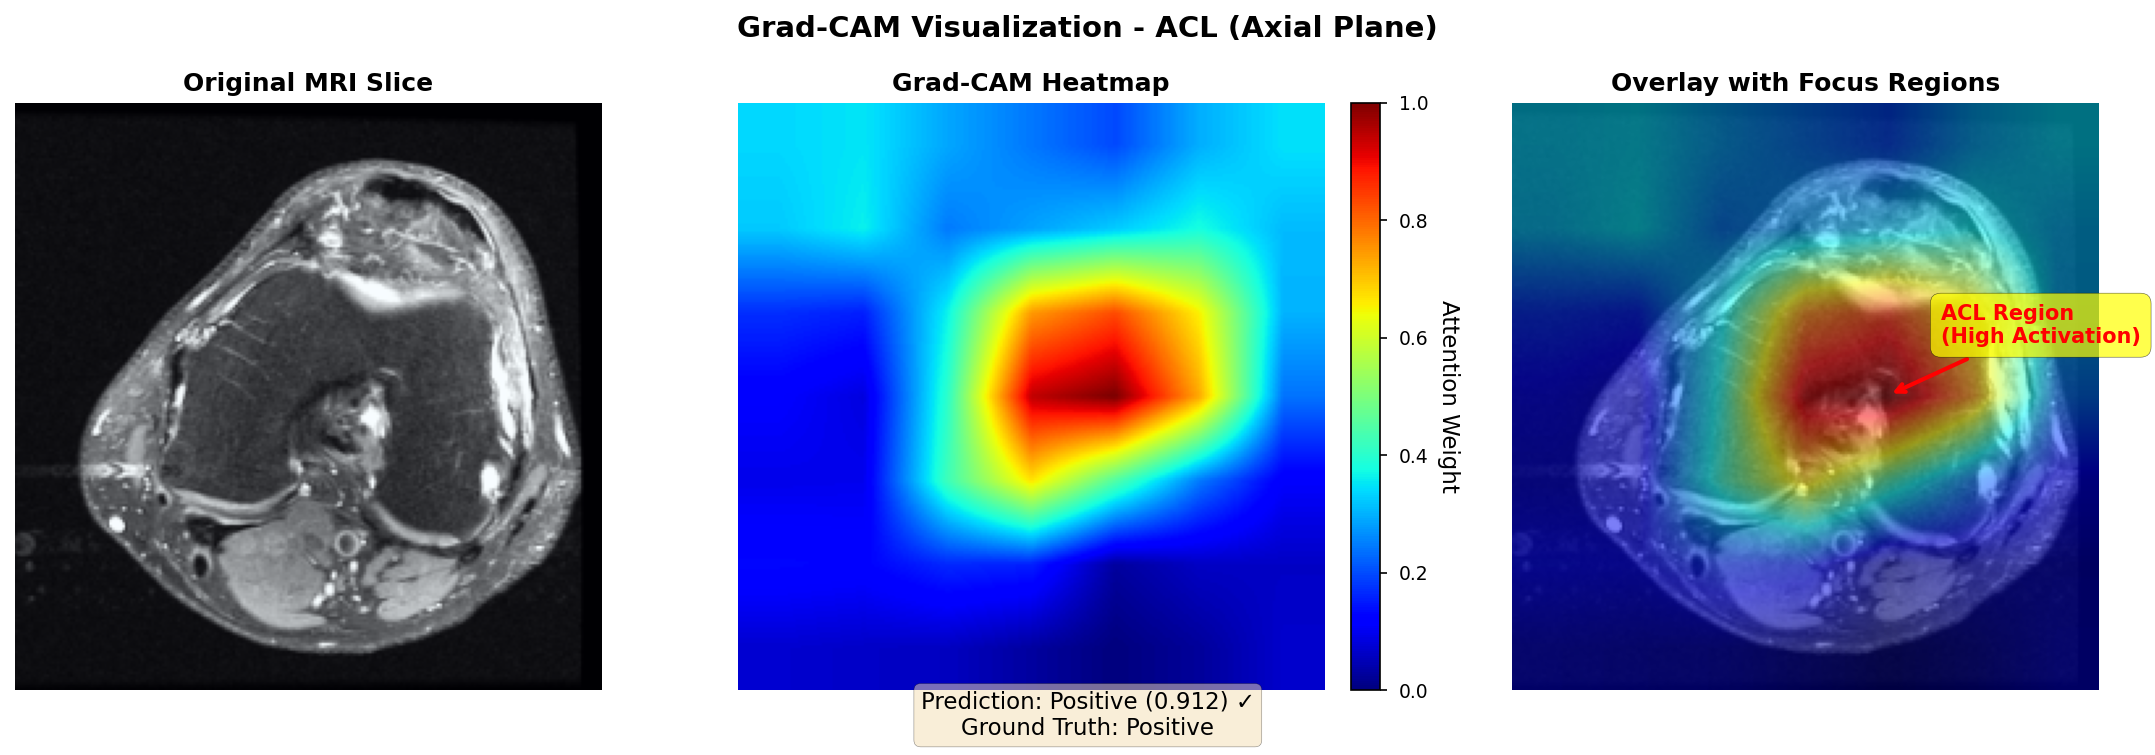


✅ Grad-CAM visualization complete!


In [28]:
# 9) Generate Grad-CAM Visualizations for Selected Samples

if len(trained_models) > 0 and 'selected_samples' in locals():
    print("="*70)
    print("Generating Grad-CAM Visualizations")
    print("="*70)
    
    # Select one plane for detailed visualization (use first available)
    demo_plane = list(trained_models.keys())[0]
    model = trained_models[demo_plane]['model']
    
    # Select one positive sample for detailed visualization
    if len(selected_samples[demo_plane]['positive']) > 0:
        sample = selected_samples[demo_plane]['positive'][0]
        
        volume = sample['volume']
        label = sample['label']
        slice_idx = sample['slice_idx']
        exam_id = sample['exam_id']
        
        print(f"\nGenerating visualization for {demo_plane.upper()} plane")
        print(f"   Exam ID: {exam_id}")
        print(f"   Label: {'Positive' if label == 1 else 'Negative'}")
        print(f"   Slice: {slice_idx}/{volume.shape[0]-1}")
        
        # Extract the specific slice
        input_slice = volume[slice_idx]  # (C, H, W)
        
        # Generate Grad-CAM
        print("\n   Generating Grad-CAM...")
        original_img, cam_heatmap, cam_overlay, confidence = generate_gradcam_visualization(
            model=model,
            input_slice=input_slice,
            target_layer_name='cbam',
            class_idx=1,
            colormap=cv2.COLORMAP_JET
        )
        
        # Example annotations (customize based on ACL anatomy)
        # For ACL tears, typically look at intercondylar notch region
        h, w = cam_heatmap.shape
        
        # Find region with highest activation
        max_y, max_x = np.unravel_index(cam_heatmap.argmax(), cam_heatmap.shape)
        
        annotations = [
            (max_x, max_y, "ACL Region\n(High Activation)")
        ]
        
        # Plot 3-panel Grad-CAM figure
        print("   Creating publication-ready figure...")
        plot_single_gradcam(
            original_img=original_img,
            cam_heatmap=cam_heatmap,
            cam_overlay=cam_overlay,
            confidence=confidence,
            true_label=label,
            title=f"Grad-CAM Visualization - {TASK.upper()} ({demo_plane.capitalize()} Plane)",
            save_path=viz_output_dir / f"gradcam_{demo_plane}_{exam_id}_slice{slice_idx}.png",
            annotations=annotations
        )
        
        print(f"\n✅ Grad-CAM visualization complete!")
    else:
        print("\n⚠️  No positive samples available for visualization")
else:
    print("\n⚠️  Skipping Grad-CAM generation - no models or samples available")

Generating Comprehensive Combined Attention Analysis

Processing sample: 1181
   Volume shape: torch.Size([25, 3, 224, 224])
   Selected slice: 12

   Slice attention for current slice: 0.1713
   Confidence: 0.9118

   Creating comprehensive 4-panel analysis...
   Saved: runs_mrnet_hybrid_fusion_npy\visualizations_acl\combined_analysis_axial_1181.png


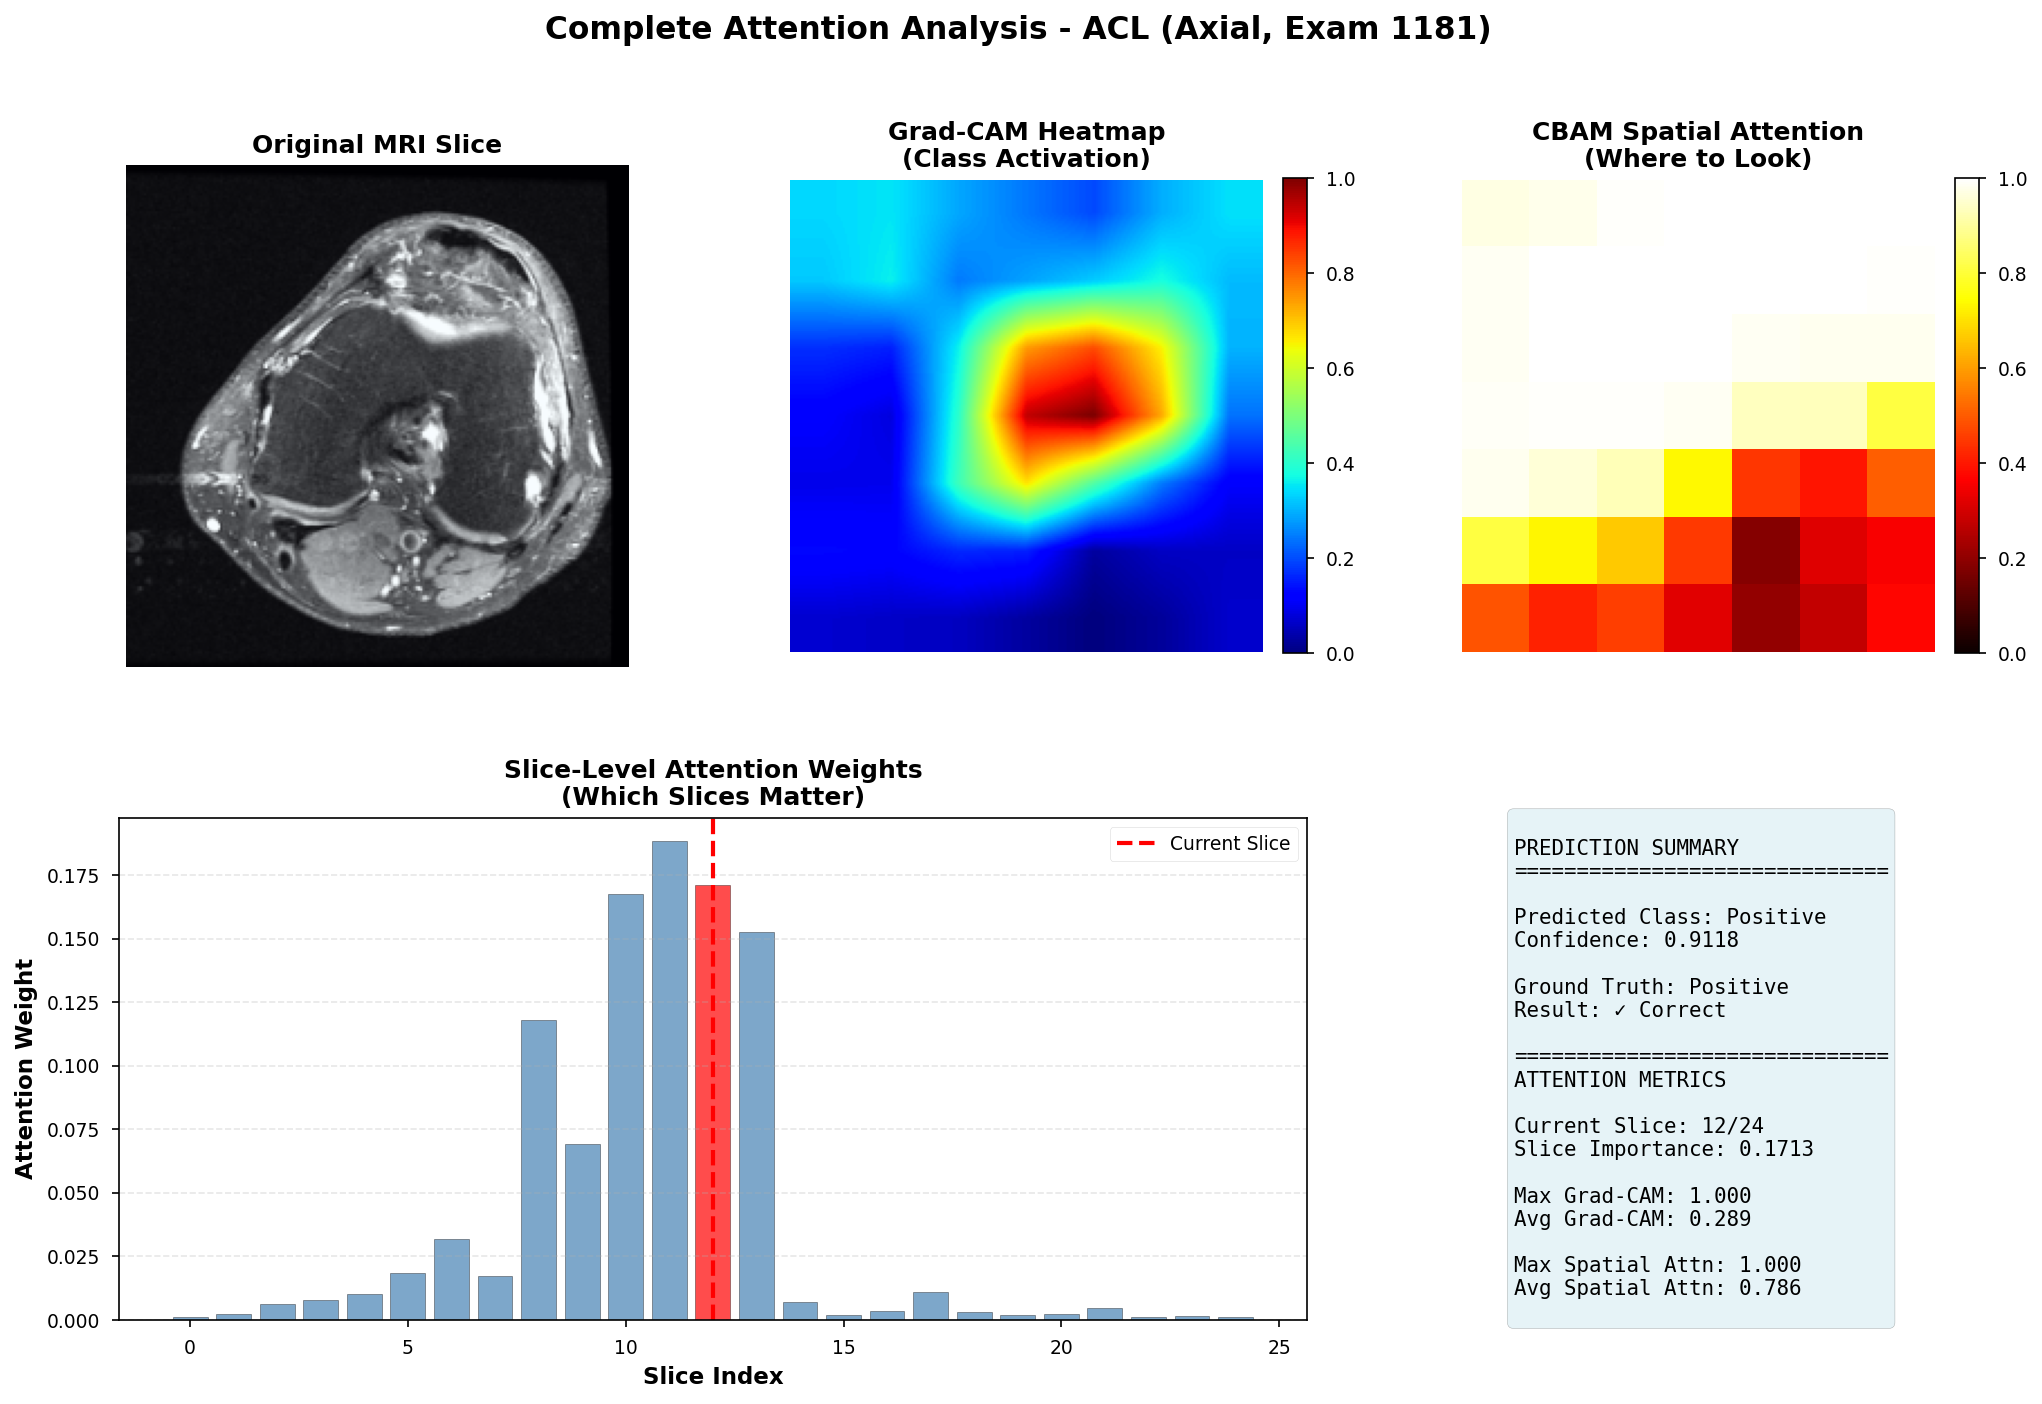


✅ Comprehensive analysis complete!


In [29]:
# 10) Generate Comprehensive Combined Attention Analysis

if len(trained_models) > 0 and 'selected_samples' in locals():
    demo_plane = list(trained_models.keys())[0]
    model = trained_models[demo_plane]['model']
    
    print("="*70)
    print("Generating Comprehensive Combined Attention Analysis")
    print("="*70)
    
    if len(selected_samples[demo_plane]['positive']) > 0:
        sample = selected_samples[demo_plane]['positive'][0]
        volume = sample['volume']
        label = sample['label']
        slice_idx = sample['slice_idx']
        exam_id = sample['exam_id']
        
        print(f"\nProcessing sample: {exam_id}")
        print(f"   Volume shape: {volume.shape}")
        print(f"   Selected slice: {slice_idx}")
        
        # 1. Generate Grad-CAM
        input_slice = volume[slice_idx]
        original_img, cam_heatmap, _, confidence = generate_gradcam_visualization(
            model=model,
            input_slice=input_slice,
            target_layer_name='cbam',
            class_idx=1
        )
        
        # 2. Extract spatial attention (if CBAM available)
        if hasattr(model, 'cbam'):
            input_batch = input_slice.unsqueeze(0).to(device)
            spatial_map = extract_spatial_attention_map(model, input_batch)
        else:
            spatial_map = np.zeros(cam_heatmap.shape)
        
        # 3. Extract slice attention weights
        if hasattr(model, 'slice_attention'):
            input_volume = volume.unsqueeze(0).to(device)  # (1, K, C, H, W)
            slice_weights = extract_slice_attention_weights(model, input_volume)
        else:
            slice_weights = np.ones(volume.shape[0]) / volume.shape[0]
        
        print(f"\n   Slice attention for current slice: {slice_weights[slice_idx]:.4f}")
        print(f"   Confidence: {confidence:.4f}")
        
        # Create comprehensive visualization
        print("\n   Creating comprehensive 4-panel analysis...")
        plot_combined_attention_analysis(
            original_img=original_img,
            cam_heatmap=cam_heatmap,
            spatial_map=spatial_map,
            slice_weights=slice_weights,
            confidence=confidence,
            true_label=label,
            slice_idx=slice_idx,
            title=f"Complete Attention Analysis - {TASK.upper()} ({demo_plane.capitalize()}, Exam {exam_id})",
            save_path=viz_output_dir / f"combined_analysis_{demo_plane}_{exam_id}.png"
        )
        
        print(f"\n✅ Comprehensive analysis complete!")
    else:
        print("\n⚠️  No samples available")
else:
    print("\n⚠️  Skipping combined analysis - no models or samples available")

Generating Positive vs Negative Case Comparison

   Positive case (Exam 1181): confidence=0.912
   Negative case (Exam 1189): confidence=0.770

   Creating positive vs negative comparison...
   Saved: runs_mrnet_hybrid_fusion_npy\visualizations_acl\pos_vs_neg_comparison_axial_acl.png


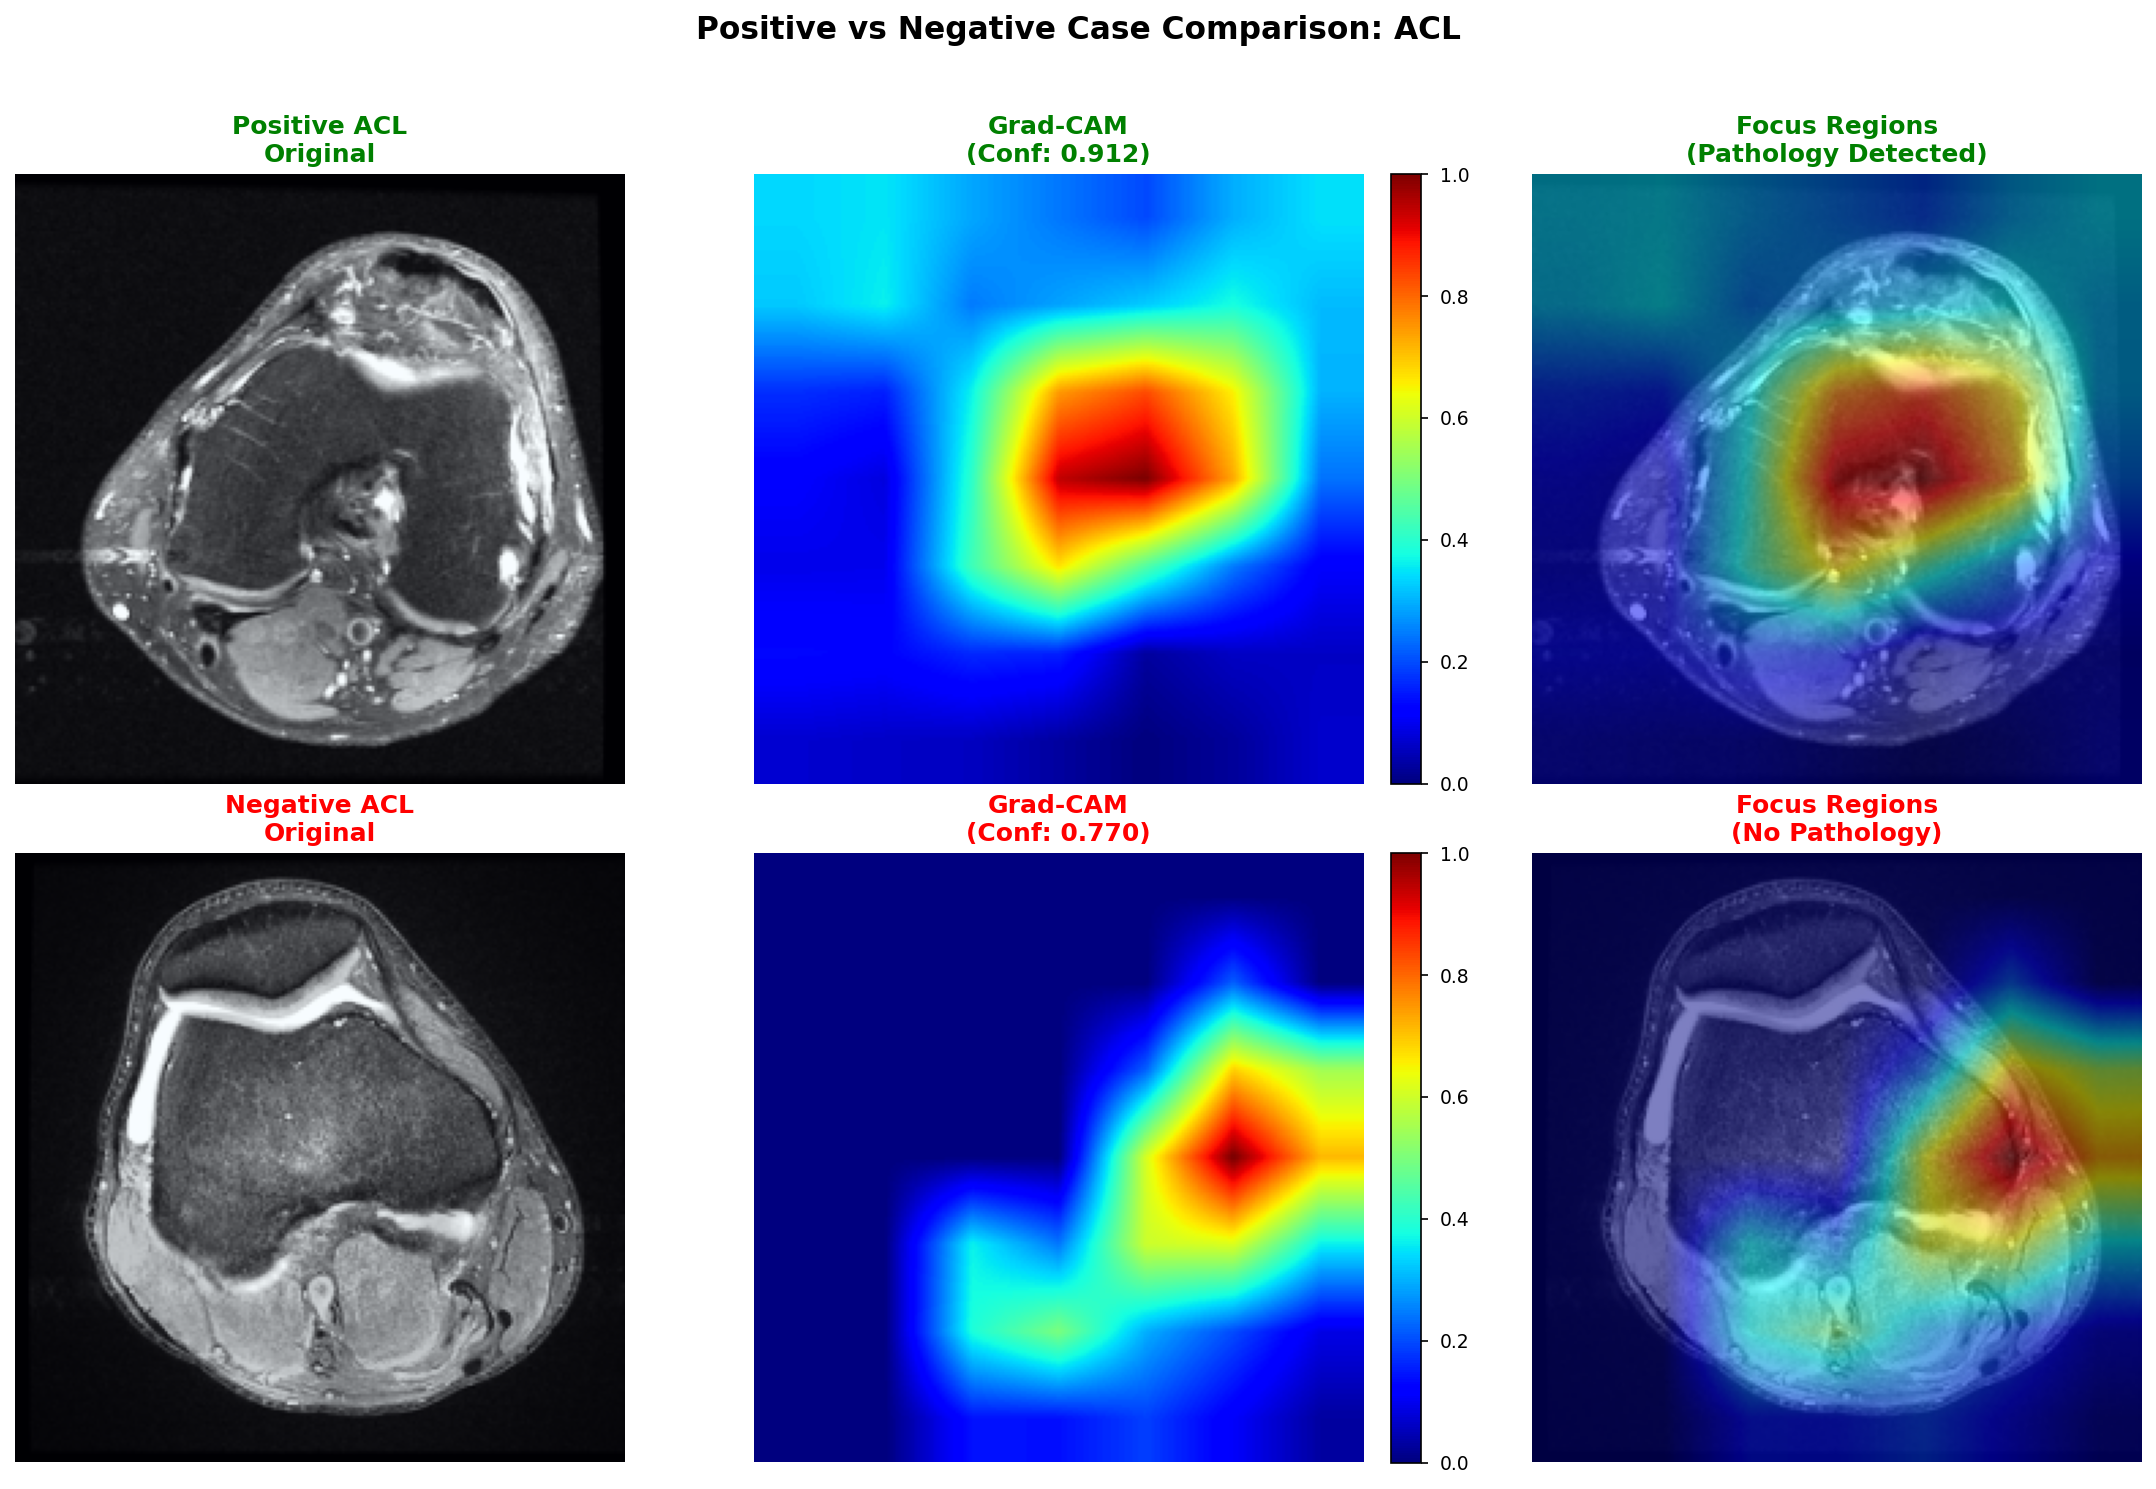


✅ Positive vs Negative comparison complete!


In [30]:
# 11) Generate Positive vs Negative Case Comparison

if len(trained_models) > 0 and 'selected_samples' in locals():
    print("="*70)
    print("Generating Positive vs Negative Case Comparison")
    print("="*70)
    
    demo_plane = list(trained_models.keys())[0]
    model = trained_models[demo_plane]['model']
    
    # Check if we have both positive and negative samples
    pos_samples = selected_samples[demo_plane]['positive']
    neg_samples = selected_samples[demo_plane]['negative']
    
    if len(pos_samples) > 0 and len(neg_samples) > 0:
        # Process positive sample
        pos_sample = pos_samples[0]
        pos_volume = pos_sample['volume']
        pos_slice_idx = pos_sample['slice_idx']
        
        pos_input_slice = pos_volume[pos_slice_idx]
        pos_img, pos_cam, _, pos_conf = generate_gradcam_visualization(
            model=model,
            input_slice=pos_input_slice,
            target_layer_name='cbam' if hasattr(model, 'cbam') else 'backbone',
            class_idx=1
        )
        
        # Process negative sample
        neg_sample = neg_samples[0]
        neg_volume = neg_sample['volume']
        neg_slice_idx = neg_sample['slice_idx']
        
        neg_input_slice = neg_volume[neg_slice_idx]
        neg_img, neg_cam, _, neg_conf = generate_gradcam_visualization(
            model=model,
            input_slice=neg_input_slice,
            target_layer_name='cbam' if hasattr(model, 'cbam') else 'backbone',
            class_idx=0
        )
        
        print(f"\n   Positive case (Exam {pos_sample['exam_id']}): confidence={pos_conf:.3f}")
        print(f"   Negative case (Exam {neg_sample['exam_id']}): confidence={neg_conf:.3f}")
        
        print("\n   Creating positive vs negative comparison...")
        plot_positive_negative_comparison(
            positive_sample=(pos_img, pos_cam, pos_conf),
            negative_sample=(neg_img, neg_cam, neg_conf),
            task_name=TASK.upper(),
            save_path=viz_output_dir / f"pos_vs_neg_comparison_{demo_plane}_{TASK}.png"
        )
        
        print(f"\n✅ Positive vs Negative comparison complete!")
    else:
        missing = []
        if len(pos_samples) == 0:
            missing.append("positive")
        if len(neg_samples) == 0:
            missing.append("negative")
        print(f"\n⚠️  Missing {' and '.join(missing)} samples")
else:
    print("\n⚠️  Skipping comparison - no models or samples available")